# Notebook 08 — Flood Susceptibility Model

## Objective

Notebook 08 marks the transition from predictor preparation and statistical
diagnostics to supervised flood-susceptibility modelling.

The validated year-specific predictor datasets generated in Notebook 06 and
analysed in Notebook 07 will be used as the foundation for constructing and
evaluating the flood-susceptibility models for 2003, 2014, and 2025.

The major objectives of this notebook are:

1. Load and verify the final predictor datasets.
2. Prepare the flood-related target/reference data.
3. Construct the modelling datasets.
4. Define the predictor and target variables.
5. Establish an appropriate training and validation strategy.
6. Train the selected machine-learning / GeoAI models.
7. Evaluate and compare model performance.
8. Analyse predictor importance and model behaviour.
9. Generate flood-susceptibility predictions for 2003, 2014, and 2025.
10. Convert predictions into spatial susceptibility rasters.
11. Perform final model and raster quality assurance.
12. Inventory all Notebook 08 outputs.

Special attention will be given to spatial data leakage, categorical treatment
of LULC, temporal consistency, class balance, and reproducibility.

No modelling decision will be made solely from a single performance metric.
Model selection will be based on the complete validation evidence and the
research objectives.

Original predictor rasters and previously validated predictor tables will not
be modified during this notebook.

## 8.1 — Load and Verify Final Predictor Datasets

### Objective

The first step of the flood-susceptibility modelling workflow is to load the
final year-specific predictor tables generated and validated in Notebook 06.

The three modelling datasets correspond to:

- 2003
- 2014
- 2025

Each dataset contains the spatial identifiers, continuous environmental
predictors, rainfall, and categorical LULC information required for the
subsequent modelling workflow.

### Expected predictor structure

Each year-specific table is expected to contain:

- `year`
- `row`
- `col`
- `x_utm`
- `y_utm`
- `Elevation`
- `Slope`
- `Flow_Accumulation`
- `River_Distance`
- `Drainage_Density`
- `Clay`
- `Sand`
- `Rainfall`
- `LULC`

The predictor datasets were already subjected to structural and spatial QA
in Notebook 06. This step independently verifies that the expected files can
be loaded correctly before modelling begins.

### Verification performed

For each year, the following will be checked:

- File existence
- Number of observations
- Expected column structure
- Year identifier
- Missing values
- Infinite values
- Duplicate spatial cells
- Coordinate availability
- LULC class validity
- Numeric predictor availability

No predictor values will be modified, imputed, resampled, or transformed in
this step.

### Expected observation counts

| Year | Expected observations |
|------|-----------------------:|
| 2003 | 47,523 |
| 2014 | 46,391 |
| 2025 | 43,076 |

Successful completion of this step confirms that the final predictor
datasets are available as modelling inputs.

In [1]:
# ============================================================
# Step 08.1 — Load and Verify Final Predictor Datasets
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


# ============================================================
# PATHS
# ============================================================

PREDICTOR_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "predictors_table"
)


PREDICTOR_FILES = {
    2003: PREDICTOR_TABLE_DIR / "predictors_2003_250m.csv",
    2014: PREDICTOR_TABLE_DIR / "predictors_2014_250m.csv",
    2025: PREDICTOR_TABLE_DIR / "predictors_2025_250m.csv",
}


EXPECTED_ROWS = {
    2003: 47523,
    2014: 46391,
    2025: 43076,
}


EXPECTED_COLUMNS = [
    "year",
    "row",
    "col",
    "x_utm",
    "y_utm",
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC",
]


CONTINUOUS_PREDICTORS = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
]


VALID_LULC_CLASSES = {
    1, 2, 3, 4, 5
}


# ============================================================
# LOAD DATASETS
# ============================================================

predictor_tables = {}


for year, file_path in PREDICTOR_FILES.items():

    print("\n" + "-" * 75)
    print(f"LOADING PREDICTOR TABLE — {year}")
    print("-" * 75)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Predictor table not found for {year}:\n"
            f"{file_path}"
        )

    df = pd.read_csv(file_path)

    predictor_tables[year] = df

    print(
        f"File       : {file_path.name}"
    )

    print(
        f"Rows       : {len(df):,}"
    )

    print(
        f"Columns    : {len(df.columns)}"
    )


# ============================================================
# STRUCTURAL VERIFICATION
# ============================================================

print("\n" + "=" * 75)
print("STRUCTURAL VERIFICATION")
print("=" * 75)


for year, df in predictor_tables.items():

    print("\n" + "-" * 75)
    print(f"YEAR — {year}")
    print("-" * 75)

    # --------------------------------------------------------
    # Row count
    # --------------------------------------------------------

    expected_rows = EXPECTED_ROWS[year]

    assert len(df) == expected_rows, (
        f"{year}: expected {expected_rows:,} rows, "
        f"found {len(df):,}"
    )

    print(
        f"Rows              : "
        f"{len(df):,} "
        f"(expected {expected_rows:,}) ✓"
    )


    # --------------------------------------------------------
    # Column structure
    # --------------------------------------------------------

    actual_columns = list(df.columns)

    assert actual_columns == EXPECTED_COLUMNS, (
        f"{year}: unexpected column structure.\n"
        f"Expected: {EXPECTED_COLUMNS}\n"
        f"Found: {actual_columns}"
    )

    print(
        "Column structure   : ✓"
    )


    # --------------------------------------------------------
    # Year identifier
    # --------------------------------------------------------

    unique_years = df["year"].unique()

    assert len(unique_years) == 1
    assert int(unique_years[0]) == year

    print(
        f"Year identifier     : "
        f"{year} ✓"
    )


    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    missing_count = int(
        df[EXPECTED_COLUMNS]
        .isna()
        .sum()
        .sum()
    )

    assert missing_count == 0, (
        f"{year}: {missing_count} missing values detected."
    )

    print(
        f"Missing values      : "
        f"{missing_count} ✓"
    )


    # --------------------------------------------------------
    # Infinite values
    # --------------------------------------------------------

    infinite_count = int(
        np.isinf(
            df[CONTINUOUS_PREDICTORS]
            .to_numpy(dtype=float)
        ).sum()
    )

    assert infinite_count == 0, (
        f"{year}: {infinite_count} infinite values detected."
    )

    print(
        f"Infinite values     : "
        f"{infinite_count} ✓"
    )


    # --------------------------------------------------------
    # Duplicate spatial cells
    # --------------------------------------------------------

    duplicate_cells = int(
        df.duplicated(
            subset=["row", "col"]
        ).sum()
    )

    assert duplicate_cells == 0, (
        f"{year}: duplicate spatial cells detected."
    )

    print(
        f"Duplicate cells     : "
        f"{duplicate_cells} ✓"
    )


    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    assert np.isfinite(
        df["x_utm"].to_numpy()
    ).all()

    assert np.isfinite(
        df["y_utm"].to_numpy()
    ).all()

    print(
        "Coordinates         : ✓"
    )


    # --------------------------------------------------------
    # LULC validity
    # --------------------------------------------------------

    lulc_classes = set(
        df["LULC"].astype(int).unique()
    )

    assert lulc_classes.issubset(
        VALID_LULC_CLASSES
    ), (
        f"{year}: invalid LULC classes detected: "
        f"{sorted(lulc_classes)}"
    )

    print(
        f"LULC classes        : "
        f"{sorted(lulc_classes)} ✓"
    )


    # --------------------------------------------------------
    # Continuous predictor availability
    # --------------------------------------------------------

    for predictor in CONTINUOUS_PREDICTORS:

        assert pd.api.types.is_numeric_dtype(
            df[predictor]
        ), (
            f"{year}: {predictor} is not numeric."
        )

    print(
        "Continuous predictors: ✓"
    )


# ============================================================
# DISPLAY DATA TYPES
# ============================================================

print("\n" + "=" * 75)
print("PREDICTOR DATA TYPES")
print("=" * 75)


for year, df in predictor_tables.items():

    print("\n" + "-" * 75)
    print(f"{year}")
    print("-" * 75)

    print(
        df.dtypes.to_string()
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.1 — FINAL STATUS")
print("=" * 75)

print(
    "✓ 2003 predictor table loaded and verified"
)

print(
    "✓ 2014 predictor table loaded and verified"
)

print(
    "✓ 2025 predictor table loaded and verified"
)

print(
    "✓ Expected column structure confirmed"
)

print(
    "✓ Expected row counts confirmed"
)

print(
    "✓ Year identifiers confirmed"
)

print(
    "✓ No missing values detected"
)

print(
    "✓ No infinite values detected"
)

print(
    "✓ No duplicate spatial cells detected"
)

print(
    "✓ UTM coordinates are valid"
)

print(
    "✓ LULC classes are valid"
)

print(
    "✓ Continuous predictors are numeric"
)

print(
    "✓ Source predictor tables were not modified"
)

print("=" * 75)
print("✓ STEP 08.1 COMPLETED")
print("=" * 75)


---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2003
---------------------------------------------------------------------------
File       : predictors_2003_250m.csv
Rows       : 47,523
Columns    : 14

---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2014
---------------------------------------------------------------------------
File       : predictors_2014_250m.csv
Rows       : 46,391
Columns    : 14

---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2025
---------------------------------------------------------------------------
File       : predictors_2025_250m.csv
Rows       : 43,076
Columns    : 14

STRUCTURAL VERIFICATION

---------------------------------------------------------------------------
YEAR — 2003
---------------------------------------------------------------------------
Rows              : 47,523 (expected

# 08.2 — Flood Target / Reference Data Preparation

## Objective

This step prepares the flood reference data required for supervised
flood-susceptibility modelling.

The predictor datasets from Notebook 06 describe the environmental conditions
of each 250 m modelling cell. A supervised machine-learning model additionally
requires a target variable indicating whether a modelling cell represents a
flooded or non-flooded condition.

The flood reference data are therefore spatially associated with the common
250 m modelling grid and converted into a binary modelling target.

### Target definition

The target variable is defined as:

- `1` — Flood
- `0` — Non-flood

The target is kept separate from the environmental predictors. It is not
treated as an environmental predictor and is not used in the predictor
correlation or VIF analyses performed in Notebook 07.

### Operations performed

1. Load the flood reference dataset.
2. Verify its spatial reference and geometry.
3. Verify that the reference data spatially correspond to the study area.
4. Associate flood-reference information with the 250 m modelling cells.
5. Construct the binary flood target.
6. Examine flood and non-flood class counts.
7. Check for duplicate modelling cells.
8. Check for missing or invalid target values.
9. Preserve the spatial row/column identifiers required for later raster
   reconstruction.
10. Save the resulting flood-target table for subsequent modelling steps.

### Important methodological rule

No environmental predictor values are modified during this step.

No missing target values are imputed automatically.

The target construction procedure is explicitly recorded so that the
supervised-learning dataset can be reproduced and described in the research
paper.

The final output of this step will provide the flood/non-flood target that
will later be joined with the validated predictor datasets.


NOTEBOOK 08 — FLOOD REFERENCE DATA LOADING

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2003
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003
TIFF files: 1
  ✓ DFO_2279_From_20030715_to_20030901.tif

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2014
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014
TIFF files: 1
  ✓ DFO_4171_From_20140811_to_20140908.tif

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2025
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025
TIFF files: 4
  ✓ AS_E027N024T3_ENSEMBLE_FLOOD_202508

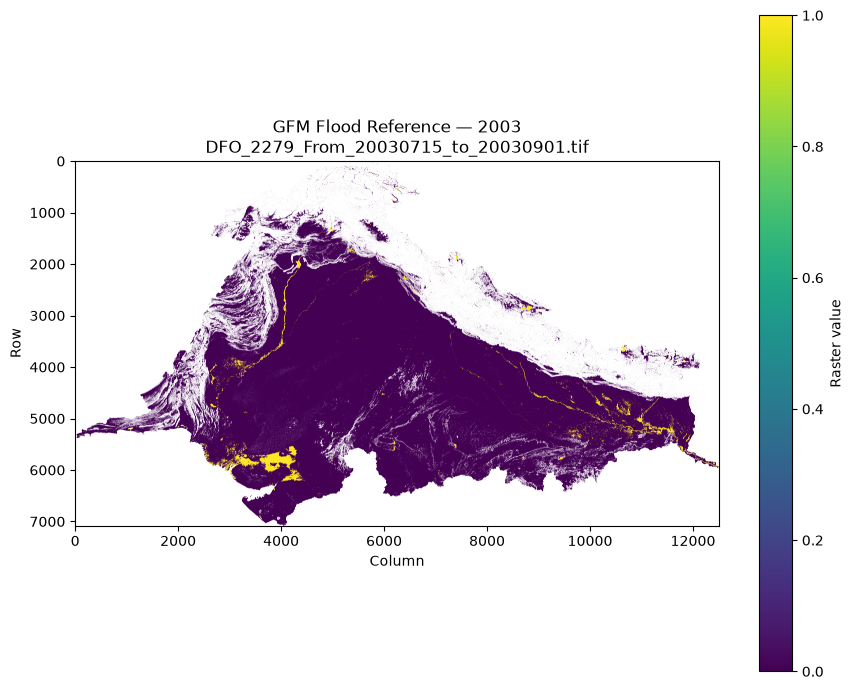

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2003_DFO_2279_From_20030715_to_20030901.png


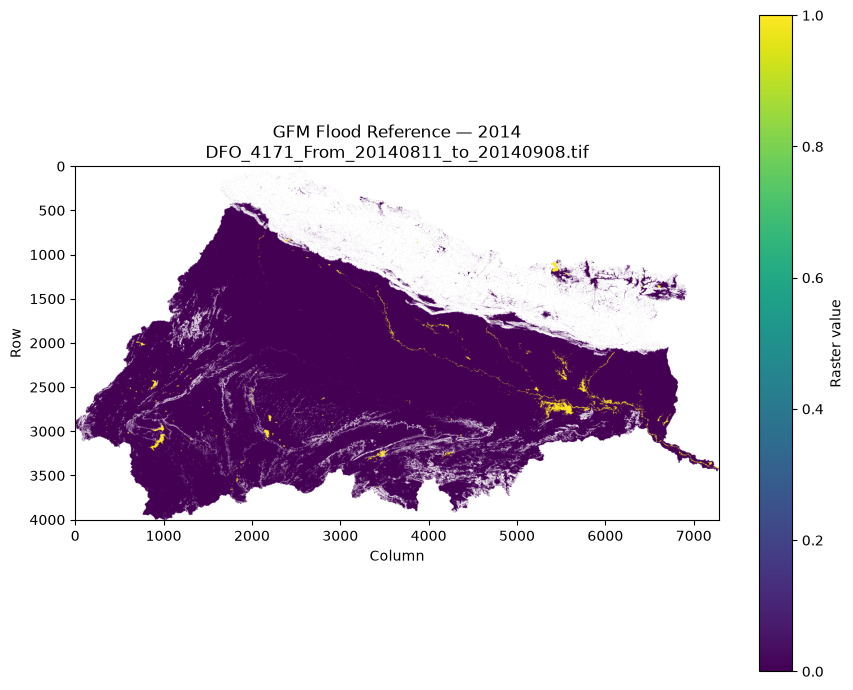

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2014_DFO_4171_From_20140811_to_20140908.png


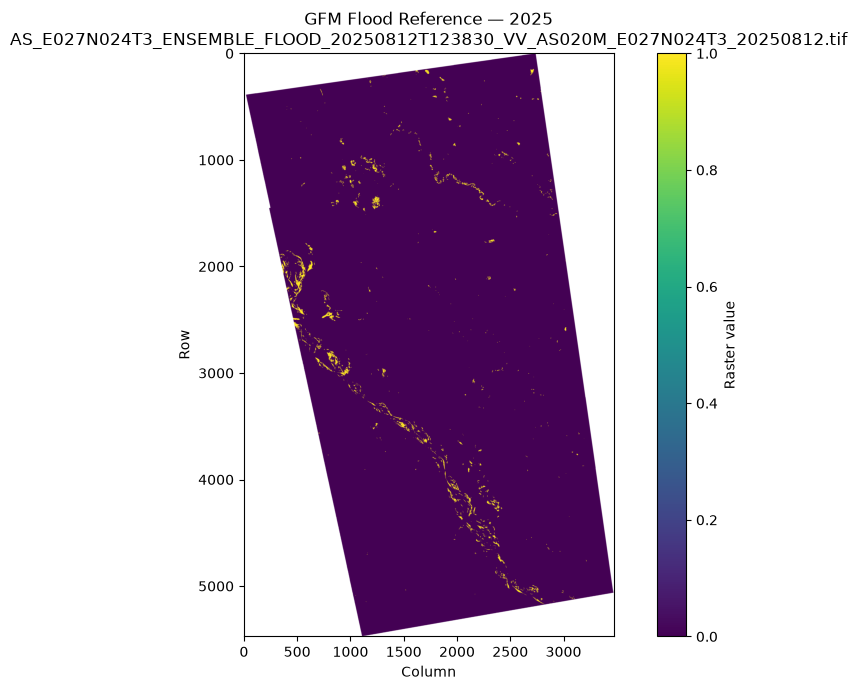

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.png


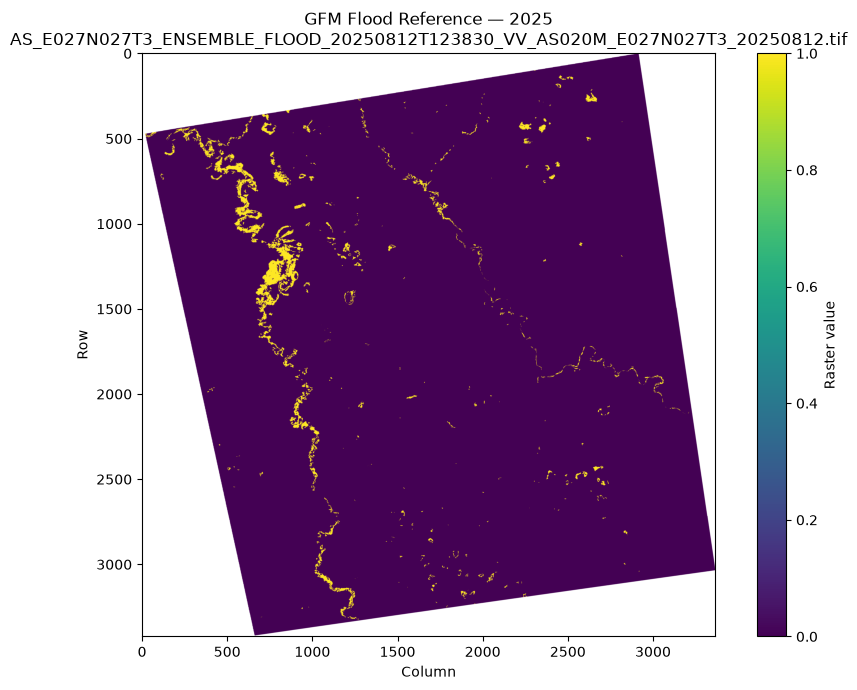

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.png


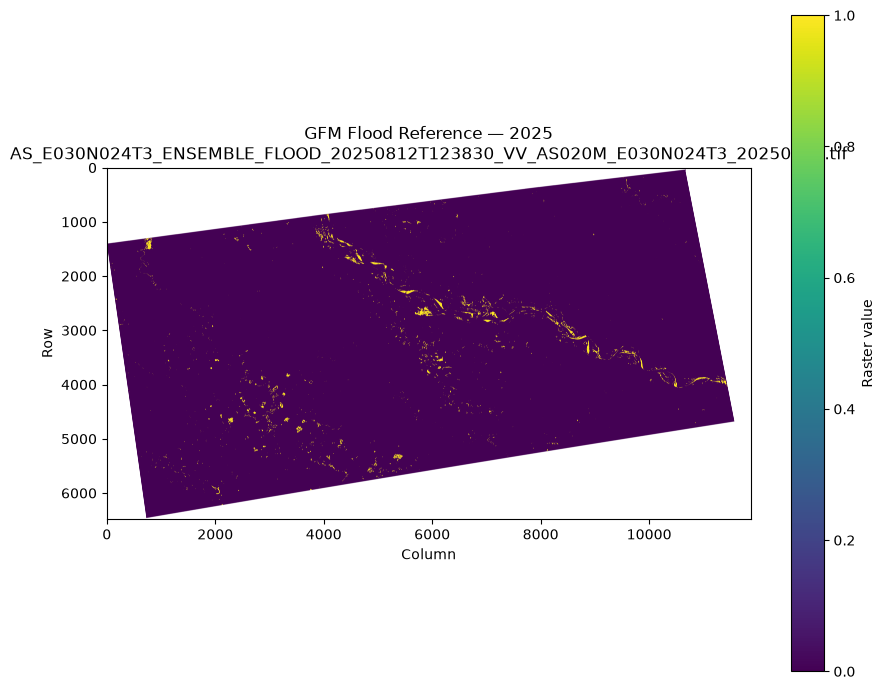

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.png


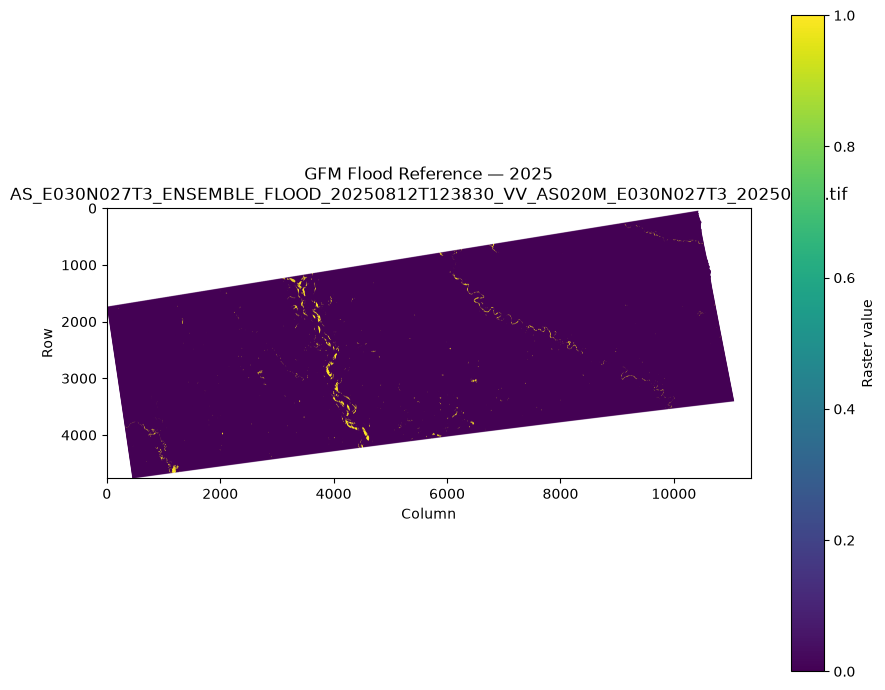

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.png

STEP 08.2 — FINAL STATUS
✓ Flood-reference directories located
✓ Flood-reference TIFF files discovered
✓ Raster metadata inspected
✓ CRS inspected
✓ Raster dimensions inspected
✓ Spatial resolution inspected
✓ NoData values inspected
✓ Valid and NoData cells counted
✓ Unique raster values inspected
✓ Initial raster visualisations generated
✓ Metadata table saved
✓ Unique-value table saved
✓ Raw flood-reference rasters were NOT modified
✓ No reprojection performed
✓ No resampling performed
✓ No clipping performed
✓ STEP 08.2 COMPLETED


In [2]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.2 — Flood Reference Data Loading & Initial Inspection
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt


# ============================================================
# 1. PROJECT PATHS
# ============================================================

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------
# If PROJECT_ROOT was already defined in previous notebooks,
# this will reuse it.
# Otherwise, set it manually to your project folder.
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path(PROJECT_ROOT)


# ------------------------------------------------------------
# Raw flood-reference directories
# ------------------------------------------------------------

FLOOD_REFERENCE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
)


YEAR_DIRECTORIES = {
    2003: FLOOD_REFERENCE_ROOT / "2003",
    2014: FLOOD_REFERENCE_ROOT / "2014",
    2025: FLOOD_REFERENCE_ROOT / "2025",
}


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_08"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FLOOD-REFERENCE FILE DISCOVERY
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE DATA LOADING")
print("=" * 75)


flood_files = {}


for year, year_dir in YEAR_DIRECTORIES.items():

    print("\n" + "-" * 75)
    print(f"FLOOD REFERENCE FILES — {year}")
    print("-" * 75)

    if not year_dir.exists():
        raise FileNotFoundError(
            f"Flood-reference directory not found:\n{year_dir}"
        )

    tif_files = sorted(
        list(year_dir.glob("*.tif"))
        + list(year_dir.glob("*.tiff"))
    )

    if len(tif_files) == 0:
        raise FileNotFoundError(
            f"No TIFF files found in:\n{year_dir}"
        )

    flood_files[year] = tif_files

    print(f"Directory : {year_dir}")
    print(f"TIFF files: {len(tif_files)}")

    for tif in tif_files:
        print(f"  ✓ {tif.name}")


# ============================================================
# 3. INITIAL RASTER METADATA INSPECTION
# ============================================================

metadata_records = []


for year, tif_files in flood_files.items():

    print("\n" + "=" * 75)
    print(f"INITIAL FLOOD-REFERENCE INSPECTION — {year}")
    print("=" * 75)

    for tif_path in tif_files:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            # ------------------------------------------------
            # Basic raster metadata
            # ------------------------------------------------

            width = src.width
            height = src.height
            count = src.count

            crs = src.crs

            resolution_x = src.res[0]
            resolution_y = src.res[1]

            transform = src.transform
            bounds = src.bounds

            dtype = src.dtypes[0]

            nodata = src.nodata

            driver = src.driver

            # ------------------------------------------------
            # Read first band
            # ------------------------------------------------

            data = src.read(1)

            # ------------------------------------------------
            # Valid mask
            # ------------------------------------------------

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            valid_cells = int(
                valid_mask.sum()
            )

            total_cells = int(
                data.size
            )

            nodata_cells = (
                total_cells
                - valid_cells
            )

            # ------------------------------------------------
            # Unique values
            # ------------------------------------------------

            if valid_cells > 0:

                unique_values = np.unique(
                    valid_values
                )

                unique_display = (
                    unique_values[:50]
                )

                minimum = float(
                    np.min(valid_values)
                )

                maximum = float(
                    np.max(valid_values)
                )

            else:

                unique_values = np.array([])

                unique_display = []

                minimum = np.nan
                maximum = np.nan

            # ------------------------------------------------
            # Print metadata
            # ------------------------------------------------

            print(f"Driver          : {driver}")
            print(f"CRS             : {crs}")
            print(
                f"Dimensions      : "
                f"{height} × {width}"
            )

            print(
                f"Resolution      : "
                f"{resolution_x} × "
                f"{resolution_y}"
            )

            print(f"Bands           : {count}")

            print(f"Data type       : {dtype}")

            print(f"NoData          : {nodata}")

            print(
                f"Valid cells     : "
                f"{valid_cells:,} / "
                f"{total_cells:,}"
            )

            print(
                f"NoData cells    : "
                f"{nodata_cells:,}"
            )

            print(
                f"Minimum         : "
                f"{minimum}"
            )

            print(
                f"Maximum         : "
                f"{maximum}"
            )

            print(
                "Unique values   : "
                f"{unique_display}"
            )

            print(f"Bounds          : {bounds}")

            print(f"Transform       : {transform}")

            # ------------------------------------------------
            # Record metadata
            # ------------------------------------------------

            metadata_records.append({

                "year": year,

                "file_name":
                    tif_path.name,

                "width":
                    width,

                "height":
                    height,

                "bands":
                    count,

                "crs":
                    str(crs),

                "resolution_x":
                    resolution_x,

                "resolution_y":
                    resolution_y,

                "dtype":
                    dtype,

                "nodata":
                    nodata,

                "total_cells":
                    total_cells,

                "valid_cells":
                    valid_cells,

                "nodata_cells":
                    nodata_cells,

                "minimum":
                    minimum,

                "maximum":
                    maximum,

                "unique_value_count":
                    len(unique_values),

                "bounds_left":
                    bounds.left,

                "bounds_bottom":
                    bounds.bottom,

                "bounds_right":
                    bounds.right,

                "bounds_top":
                    bounds.top
            })


# ============================================================
# 4. METADATA SUMMARY TABLE
# ============================================================

metadata_df = pd.DataFrame(
    metadata_records
)


metadata_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_metadata.csv"
)


metadata_df.to_csv(
    metadata_output,
    index=False
)


print("\n" + "=" * 75)
print("FLOOD-REFERENCE METADATA SUMMARY")
print("=" * 75)

print(
    metadata_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Metadata table saved:\n"
    f"{metadata_output}"
)


# ============================================================
# 5. UNIQUE-VALUE INSPECTION
# ============================================================

print("\n" + "=" * 75)
print("FLOOD-REFERENCE VALUE INSPECTION")
print("=" * 75)


value_records = []


for year, tif_files in flood_files.items():

    for tif_path in tif_files:

        with rasterio.open(tif_path) as src:

            data = src.read(1)

            nodata = src.nodata

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            unique_values, counts = np.unique(
                valid_values,
                return_counts=True
            )

            print("\n" + "-" * 75)
            print(f"{year} — {tif_path.name}")
            print("-" * 75)

            for value, count in zip(
                unique_values,
                counts
            ):

                percentage = (
                    count
                    / len(valid_values)
                    * 100
                )

                print(
                    f"Value {value}"
                    f" : {count:,} cells"
                    f" | {percentage:.4f}%"
                )

                value_records.append({

                    "year": year,

                    "file_name":
                        tif_path.name,

                    "value":
                        float(value),

                    "cell_count":
                        int(count),

                    "percentage":
                        float(percentage)
                })


value_df = pd.DataFrame(
    value_records
)


value_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_unique_values.csv"
)


value_df.to_csv(
    value_output,
    index=False
)


print(
    f"\n✓ Unique-value table saved:\n"
    f"{value_output}"
)


# ============================================================
# 6. QUICK VISUAL INSPECTION
# ============================================================
#
# This is ONLY a visual inspection.
#
# No raster is modified.
# No reprojection is performed.
# No resampling is performed.
# No clipping is performed.
#
# For multiple 2025 tiles, each tile is plotted separately.
# ============================================================

print("\n" + "=" * 75)
print("FLOOD-REFERENCE VISUAL INSPECTION")
print("=" * 75)


figure_records = []


for year, tif_files in flood_files.items():

    for tif_path in tif_files:

        with rasterio.open(tif_path) as src:

            data = src.read(1)

            nodata = src.nodata

            if nodata is not None:

                display_data = np.ma.masked_equal(
                    data,
                    nodata
                )

            else:

                display_data = np.ma.masked_invalid(
                    data
                )

            fig, ax = plt.subplots(
                figsize=(9, 7)
            )

            image = ax.imshow(
                display_data
            )

            ax.set_title(
                f"GFM Flood Reference — {year}\n"
                f"{tif_path.name}"
            )

            ax.set_xlabel(
                "Column"
            )

            ax.set_ylabel(
                "Row"
            )

            fig.colorbar(
                image,
                ax=ax,
                label="Raster value"
            )

            plt.tight_layout()

            figure_name = (
                f"flood_reference_"
                f"{year}_"
                f"{tif_path.stem}.png"
            )

            figure_path = (
                FIGURE_DIR
                / figure_name
            )

            fig.savefig(
                figure_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()

            plt.close(fig)

            figure_records.append({

                "year": year,

                "file_name":
                    tif_path.name,

                "figure":
                    str(figure_path)
            })

            print(
                f"✓ Figure saved:\n"
                f"{figure_path}"
            )


# ============================================================
# 7. FINAL STEP 08.2 STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.2 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Flood-reference directories located"
)

print(
    "✓ Flood-reference TIFF files discovered"
)

print(
    "✓ Raster metadata inspected"
)

print(
    "✓ CRS inspected"
)

print(
    "✓ Raster dimensions inspected"
)

print(
    "✓ Spatial resolution inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Valid and NoData cells counted"
)

print(
    "✓ Unique raster values inspected"
)

print(
    "✓ Initial raster visualisations generated"
)

print(
    "✓ Metadata table saved"
)

print(
    "✓ Unique-value table saved"
)

print(
    "✓ Raw flood-reference rasters were NOT modified"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print("=" * 75)
print("✓ STEP 08.2 COMPLETED")
print("=" * 75)

# Step 08.3 — Flood Reference Raster Quality Assurance

## Objective

This step performs quality assurance on the raw flood-reference rasters for
2003, 2014, and 2025 before any spatial transformation or integration with
the predictor datasets.

The purpose is to verify that the downloaded flood-reference datasets have
valid and interpretable raster structures and that the 2025 multi-tile GFM
products are internally consistent.

## Quality Checks

The following properties are assessed:

- Coordinate reference system (CRS)
- Raster dimensions
- Spatial resolution
- Number of bands
- Data type
- NoData definition
- Valid-cell counts
- Raster spatial bounds
- Unique raster values
- Flood/non-flood value structure
- Within-year consistency of 2025 GFM tiles

## Important methodological rule

The raw flood-reference rasters are treated as source/reference data.

Therefore:

- No raster values are modified.
- No missing values are imputed.
- No clipping is performed.
- No reprojection is performed.
- No resampling is performed.
- No mosaicking is performed.
- No flood class is manually recoded at this stage.

Any required spatial harmonisation will be performed in a subsequent step.

## Expected Outcome

The step should establish whether each flood-reference raster is suitable
for subsequent spatial harmonisation and conversion into the flood target
variable required for machine-learning modelling.

**Step 08.3 does not train any machine-learning model.**

In [3]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.3 — Flood Reference Raster Quality Assurance
# ============================================================

import numpy as np
import pandas as pd
import rasterio


# ============================================================
# 1. VERIFY FLOOD FILES FROM STEP 08.2
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE RASTER QA")
print("=" * 75)

if "flood_files" not in globals():
    raise RuntimeError(
        "flood_files was not found. "
        "Run Step 08.2 before Step 08.3."
    )


# ============================================================
# 2. EXPECTED FLOOD-REFERENCE YEARS
# ============================================================

EXPECTED_YEARS = [2003, 2014, 2025]

for year in EXPECTED_YEARS:

    if year not in flood_files:
        raise ValueError(
            f"Flood-reference files for {year} were not loaded."
        )

    if len(flood_files[year]) == 0:
        raise ValueError(
            f"No flood-reference TIFFs found for {year}."
        )


print("\n✓ Flood-reference years detected:")
print("  2003")
print("  2014")
print("  2025")


# ============================================================
# 3. RASTER-LEVEL QA
# ============================================================

qa_records = []


for year in EXPECTED_YEARS:

    print("\n" + "=" * 75)
    print(f"YEAR — {year}")
    print("=" * 75)

    for tif_path in flood_files[year]:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            # ------------------------------------------------
            # Metadata
            # ------------------------------------------------

            width = src.width
            height = src.height
            band_count = src.count

            crs = src.crs
            dtype = src.dtypes[0]
            nodata = src.nodata

            res_x = src.res[0]
            res_y = src.res[1]

            bounds = src.bounds
            transform = src.transform

            # ------------------------------------------------
            # Read first band
            # ------------------------------------------------

            data = src.read(1)

            # ------------------------------------------------
            # Valid-data mask
            # ------------------------------------------------

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            total_cells = data.size
            valid_cells = int(valid_mask.sum())
            nodata_cells = (
                total_cells - valid_cells
            )

            # ------------------------------------------------
            # Unique values
            # ------------------------------------------------

            if valid_cells > 0:

                unique_values, counts = np.unique(
                    valid_values,
                    return_counts=True
                )

            else:

                unique_values = np.array([])
                counts = np.array([])

            # ------------------------------------------------
            # Flood value detection
            #
            # We DO NOT recode anything.
            # We only report whether value 1 exists.
            # ------------------------------------------------

            contains_zero = (
                0 in unique_values
            )

            contains_one = (
                1 in unique_values
            )

            contains_other_values = any(
                value not in [0, 1]
                for value in unique_values
            )

            # ------------------------------------------------
            # Flood-cell count if binary 0/1
            # ------------------------------------------------

            if contains_one:

                flood_cells = int(
                    np.sum(valid_values == 1)
                )

            else:

                flood_cells = 0

            if valid_cells > 0:

                flood_percentage = (
                    flood_cells
                    / valid_cells
                    * 100
                )

            else:

                flood_percentage = np.nan

            # ------------------------------------------------
            # QA flags
            # ------------------------------------------------

            dimensions_valid = (
                width > 0
                and height > 0
            )

            band_valid = (
                band_count == 1
            )

            resolution_valid = (
                res_x > 0
                and res_y > 0
            )

            valid_data_exists = (
                valid_cells > 0
            )

            binary_values = (
                valid_cells > 0
                and all(
                    value in [0, 1]
                    for value in unique_values
                )
            )

            # ------------------------------------------------
            # Print results
            # ------------------------------------------------

            print(
                f"CRS              : {crs}"
            )

            print(
                f"Dimensions        : "
                f"{height} × {width}"
            )

            print(
                f"Bands             : {band_count}"
            )

            print(
                f"Data type         : {dtype}"
            )

            print(
                f"Resolution        : "
                f"{res_x} × {res_y}"
            )

            print(
                f"NoData            : {nodata}"
            )

            print(
                f"Total cells       : "
                f"{total_cells:,}"
            )

            print(
                f"Valid cells       : "
                f"{valid_cells:,}"
            )

            print(
                f"NoData cells      : "
                f"{nodata_cells:,}"
            )

            print(
                f"Unique values     : "
                f"{unique_values}"
            )

            print(
                f"Contains 0        : "
                f"{contains_zero}"
            )

            print(
                f"Contains 1        : "
                f"{contains_one}"
            )

            print(
                f"Contains other    : "
                f"{contains_other_values}"
            )

            print(
                f"Binary 0/1        : "
                f"{binary_values}"
            )

            print(
                f"Flood cells (1)   : "
                f"{flood_cells:,}"
            )

            print(
                f"Flood share       : "
                f"{flood_percentage:.4f}%"
            )

            print(
                f"Bounds            : "
                f"{bounds}"
            )

            # ------------------------------------------------
            # Store QA record
            # ------------------------------------------------

            qa_records.append({

                "year":
                    year,

                "file_name":
                    tif_path.name,

                "width":
                    width,

                "height":
                    height,

                "bands":
                    band_count,

                "crs":
                    str(crs),

                "dtype":
                    dtype,

                "resolution_x":
                    res_x,

                "resolution_y":
                    res_y,

                "nodata":
                    nodata,

                "total_cells":
                    total_cells,

                "valid_cells":
                    valid_cells,

                "nodata_cells":
                    nodata_cells,

                "unique_value_count":
                    len(unique_values),

                "unique_values":
                    ",".join(
                        str(v)
                        for v in unique_values
                    ),

                "contains_zero":
                    contains_zero,

                "contains_one":
                    contains_one,

                "contains_other_values":
                    contains_other_values,

                "binary_0_1":
                    binary_values,

                "flood_cells_value_1":
                    flood_cells,

                "flood_percentage":
                    flood_percentage,

                "bounds_left":
                    bounds.left,

                "bounds_bottom":
                    bounds.bottom,

                "bounds_right":
                    bounds.right,

                "bounds_top":
                    bounds.top,

                "dimensions_valid":
                    dimensions_valid,

                "single_band":
                    band_valid,

                "resolution_valid":
                    resolution_valid,

                "valid_data_exists":
                    valid_data_exists
            })


# ============================================================
# 4. QA TABLE
# ============================================================

qa_df = pd.DataFrame(
    qa_records
)


qa_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_raster_QA.csv"
)


qa_df.to_csv(
    qa_output,
    index=False
)


print("\n" + "=" * 75)
print("FLOOD REFERENCE RASTER QA SUMMARY")
print("=" * 75)

print(
    qa_df[
        [
            "year",
            "file_name",
            "crs",
            "width",
            "height",
            "bands",
            "resolution_x",
            "resolution_y",
            "dtype",
            "nodata",
            "unique_values",
            "binary_0_1",
            "flood_cells_value_1",
            "flood_percentage"
        ]
    ].to_string(index=False)
)

print(
    f"\n✓ QA table saved:\n"
    f"{qa_output}"
)


# ============================================================
# 5. WITHIN-YEAR CONSISTENCY CHECK — 2025
# ============================================================
#
# 2025 contains multiple GFM tiles.
#
# We check whether all tiles share:
# - CRS
# - resolution
# - band count
# - data type
#
# We do NOT require identical dimensions or bounds because
# different tiles naturally cover different spatial areas.
# ============================================================

print("\n" + "=" * 75)
print("2025 GFM TILE CONSISTENCY CHECK")
print("=" * 75)


gfm_2025 = qa_df[
    qa_df["year"] == 2025
].copy()


if len(gfm_2025) == 0:

    raise ValueError(
        "No 2025 flood-reference tiles found."
    )


crs_consistent = (
    gfm_2025["crs"].nunique() == 1
)

resolution_x_consistent = (
    gfm_2025["resolution_x"].nunique() == 1
)

resolution_y_consistent = (
    gfm_2025["resolution_y"].nunique() == 1
)

band_consistent = (
    gfm_2025["bands"].nunique() == 1
)

dtype_consistent = (
    gfm_2025["dtype"].nunique() == 1
)


print(
    f"CRS consistency        : "
    f"{crs_consistent}"
)

print(
    f"X-resolution consistency: "
    f"{resolution_x_consistent}"
)

print(
    f"Y-resolution consistency: "
    f"{resolution_y_consistent}"
)

print(
    f"Band-count consistency  : "
    f"{band_consistent}"
)

print(
    f"Data-type consistency   : "
    f"{dtype_consistent}"
)


gfm_consistent = all([
    crs_consistent,
    resolution_x_consistent,
    resolution_y_consistent,
    band_consistent,
    dtype_consistent
])


if gfm_consistent:

    print(
        "\n✓ 2025 GFM tiles are internally "
        "consistent in raster structure."
    )

else:

    print(
        "\n⚠ 2025 GFM tiles require further "
        "investigation before mosaicking."
    )


# ============================================================
# 6. VALUE-STRUCTURE QA
# ============================================================

print("\n" + "=" * 75)
print("FLOOD VALUE STRUCTURE QA")
print("=" * 75)


all_binary = qa_df["binary_0_1"].all()


print(
    f"All rasters binary 0/1 : "
    f"{all_binary}"
)


if all_binary:

    print(
        "✓ All valid raster values are "
        "restricted to 0 and 1."
    )

else:

    print(
        "⚠ One or more rasters contain "
        "values other than 0 and 1."
    )

    print(
        "Do NOT recode them yet."
    )


# ============================================================
# 7. FINAL QA STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.3 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Raw flood-reference rasters inspected"
)

print(
    "✓ Raster dimensions verified"
)

print(
    "✓ Band counts verified"
)

print(
    "✓ CRS inspected"
)

print(
    "✓ Spatial resolution inspected"
)

print(
    "✓ Data types inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Spatial bounds inspected"
)

print(
    "✓ Unique raster values inspected"
)

print(
    "✓ Flood-value presence assessed"
)

print(
    "✓ Flood-cell counts calculated"
)

print(
    "✓ Flood percentage calculated"
)

print(
    "✓ 2025 GFM tile consistency assessed"
)

print(
    "✓ QA results saved as CSV"
)

print(
    "✓ No raster was modified"
)

print(
    "✓ No values were recoded"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No mosaicking performed"
)

print("=" * 75)
print("✓ STEP 08.3 COMPLETED")
print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE RASTER QA

✓ Flood-reference years detected:
  2003
  2014
  2025

YEAR — 2003

---------------------------------------------------------------------------
FILE — DFO_2279_From_20030715_to_20030901.tif
---------------------------------------------------------------------------
CRS              : EPSG:4326
Dimensions        : 7080 × 12506
Bands             : 5
Data type         : float32
Resolution        : 0.002245788210298804 × 0.002245788210298804
NoData            : None
Total cells       : 88,542,480
Valid cells       : 29,640,663
NoData cells      : 58,901,817
Unique values     : [0. 1.]
Contains 0        : True
Contains 1        : True
Contains other    : False
Binary 0/1        : True
Flood cells (1)   : 764,407
Flood share       : 2.5789%
Bounds            : BoundingBox(left=61.664852678384555, bottom=21.19799491701041, right=89.7506800363814, top=37.09817544592594)

YEAR — 2014

--------------------------------------------------------------------

# Step 08.4 — Flood Reference Band Identification & Semantic QA

## Objective

The flood-reference datasets obtained from different sources may contain
different numbers of raster bands and different data structures.

The 2003 and 2014 flood-reference rasters contain multiple bands, whereas
the 2025 GFM products contain a single band.

Before constructing the flood target variable, this step identifies and
documents the semantic meaning and numerical structure of each raster band.

## Checks Performed

For every flood-reference TIFF:

- Number of bands
- Band descriptions
- Band metadata/tags
- Data type
- NoData value
- Minimum and maximum values
- Unique values
- Valid-cell count
- Binary/non-binary structure

## Important methodological rule

No assumption is made that Band 1 represents flood extent.

The flood-reference band will only be selected after its metadata and
numerical structure have been inspected.

No raster values are modified in this step.

No reprojection, resampling, clipping, mosaicking, or recoding is performed.

## Expected Outcome

The step will establish:

1. The meaning of each available raster band.
2. Which band should be used as the flood-reference variable for 2003.
3. Which band should be used for 2014.
4. The structure of the single-band 2025 GFM products.

This information is required before spatial harmonisation and construction
of the machine-learning target variable.

In [4]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.4 — Flood Reference Band Identification & Semantic QA
# ============================================================

import numpy as np
import pandas as pd
import rasterio


# ============================================================
# 1. VERIFY INPUTS FROM STEP 08.2
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE BAND IDENTIFICATION")
print("=" * 75)

if "flood_files" not in globals():
    raise RuntimeError(
        "flood_files was not found. "
        "Run Step 08.2 before Step 08.4."
    )


# ============================================================
# 2. BAND-LEVEL INSPECTION
# ============================================================

band_records = []


for year in sorted(flood_files.keys()):

    print("\n" + "=" * 75)
    print(f"YEAR — {year}")
    print("=" * 75)

    for tif_path in flood_files[year]:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            print(f"Number of bands : {src.count}")
            print(f"CRS             : {src.crs}")
            print(f"Data types      : {src.dtypes}")
            print(f"NoData          : {src.nodatavals}")

            # ------------------------------------------------
            # Dataset-level tags
            # ------------------------------------------------

            dataset_tags = src.tags()

            if dataset_tags:

                print("\nDataset tags:")

                for key, value in dataset_tags.items():

                    print(
                        f"  {key}: {value}"
                    )

            else:

                print(
                    "\nDataset tags: None"
                )

            # ------------------------------------------------
            # Inspect every band
            # ------------------------------------------------

            for band_number in range(
                1,
                src.count + 1
            ):

                print("\n" + "-" * 60)
                print(
                    f"BAND {band_number}"
                )
                print("-" * 60)

                # --------------------------------------------
                # Band description
                # --------------------------------------------

                description = (
                    src.descriptions[
                        band_number - 1
                    ]
                )

                print(
                    f"Description : "
                    f"{description}"
                )

                # --------------------------------------------
                # Band-specific tags
                # --------------------------------------------

                band_tags = src.tags(
                    band_number
                )

                if band_tags:

                    print("Band tags:")

                    for key, value in band_tags.items():

                        print(
                            f"  {key}: {value}"
                        )

                else:

                    print(
                        "Band tags: None"
                    )

                # --------------------------------------------
                # Read band
                # --------------------------------------------

                data = src.read(
                    band_number
                )

                nodata = src.nodatavals[
                    band_number - 1
                ]

                # --------------------------------------------
                # Valid mask
                # --------------------------------------------

                if nodata is None:

                    valid_mask = (
                        np.isfinite(data)
                    )

                else:

                    valid_mask = (
                        np.isfinite(data)
                        & (data != nodata)
                    )

                valid_values = data[
                    valid_mask
                ]

                valid_cells = int(
                    valid_mask.sum()
                )

                total_cells = int(
                    data.size
                )

                # --------------------------------------------
                # Statistics
                # --------------------------------------------

                if valid_cells > 0:

                    minimum = float(
                        np.min(valid_values)
                    )

                    maximum = float(
                        np.max(valid_values)
                    )

                    mean = float(
                        np.mean(valid_values)
                    )

                    unique_values = np.unique(
                        valid_values
                    )

                else:

                    minimum = np.nan
                    maximum = np.nan
                    mean = np.nan

                    unique_values = np.array([])

                # --------------------------------------------
                # Determine whether binary
                # --------------------------------------------

                is_binary_01 = (
                    valid_cells > 0
                    and np.all(
                        np.isin(
                            unique_values,
                            [0, 1]
                        )
                    )
                )

                # --------------------------------------------
                # Count 0 and 1
                # --------------------------------------------

                zero_count = int(
                    np.sum(
                        valid_values == 0
                    )
                )

                one_count = int(
                    np.sum(
                        valid_values == 1
                    )
                )

                # --------------------------------------------
                # Print statistics
                # --------------------------------------------

                print(
                    f"Data type   : "
                    f"{src.dtypes[band_number - 1]}"
                )

                print(
                    f"NoData      : "
                    f"{nodata}"
                )

                print(
                    f"Total cells : "
                    f"{total_cells:,}"
                )

                print(
                    f"Valid cells : "
                    f"{valid_cells:,}"
                )

                print(
                    f"Minimum     : "
                    f"{minimum}"
                )

                print(
                    f"Maximum     : "
                    f"{maximum}"
                )

                print(
                    f"Mean        : "
                    f"{mean}"
                )

                print(
                    f"Unique count: "
                    f"{len(unique_values)}"
                )

                print(
                    f"Unique values: "
                    f"{unique_values[:50]}"
                )

                print(
                    f"Zero cells  : "
                    f"{zero_count:,}"
                )

                print(
                    f"One cells   : "
                    f"{one_count:,}"
                )

                print(
                    f"Binary 0/1  : "
                    f"{is_binary_01}"
                )

                # --------------------------------------------
                # Store record
                # --------------------------------------------

                band_records.append({

                    "year":
                        year,

                    "file_name":
                        tif_path.name,

                    "band":
                        band_number,

                    "description":
                        description,

                    "dtype":
                        src.dtypes[
                            band_number - 1
                        ],

                    "nodata":
                        nodata,

                    "total_cells":
                        total_cells,

                    "valid_cells":
                        valid_cells,

                    "minimum":
                        minimum,

                    "maximum":
                        maximum,

                    "mean":
                        mean,

                    "unique_value_count":
                        len(unique_values),

                    "unique_values":
                        ",".join(
                            str(v)
                            for v in unique_values[:100]
                        ),

                    "zero_cells":
                        zero_count,

                    "one_cells":
                        one_count,

                    "binary_0_1":
                        is_binary_01
                })


# ============================================================
# 3. SAVE BAND INVENTORY
# ============================================================

band_df = pd.DataFrame(
    band_records
)


band_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_band_inventory.csv"
)


band_df.to_csv(
    band_output,
    index=False
)


print("\n" + "=" * 75)
print("BAND INVENTORY")
print("=" * 75)

print(
    band_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Band inventory saved:\n"
    f"{band_output}"
)


# ============================================================
# 4. SUMMARY BY YEAR
# ============================================================

print("\n" + "=" * 75)
print("BAND STRUCTURE SUMMARY")
print("=" * 75)


for year in sorted(
    band_df["year"].unique()
):

    year_df = band_df[
        band_df["year"] == year
    ]

    print("\n" + "-" * 75)
    print(f"{year}")
    print("-" * 75)

    print(
        f"Files : "
        f"{year_df['file_name'].nunique()}"
    )

    print(
        f"Bands : "
        f"{year_df['band'].nunique()}"
    )

    print(
        year_df[
            [
                "file_name",
                "band",
                "description",
                "dtype",
                "minimum",
                "maximum",
                "unique_value_count",
                "binary_0_1"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 5. CHECK FOR BAND DESCRIPTIONS
# ============================================================

print("\n" + "=" * 75)
print("BAND DESCRIPTION CHECK")
print("=" * 75)


missing_descriptions = band_df[
    band_df["description"].isna()
    | (
        band_df["description"]
        .astype(str)
        .str.strip()
        .isin(
            ["", "None"]
        )
    )
]


if len(missing_descriptions) == 0:

    print(
        "✓ All bands have descriptions."
    )

else:

    print(
        f"⚠ {len(missing_descriptions)} "
        "bands have no explicit description."
    )

    print(
        missing_descriptions[
            [
                "year",
                "file_name",
                "band"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 6. BINARY BAND SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("BINARY BAND SUMMARY")
print("=" * 75)


binary_df = band_df[
    band_df["binary_0_1"] == True
].copy()


if len(binary_df) > 0:

    print(
        binary_df[
            [
                "year",
                "file_name",
                "band",
                "description",
                "zero_cells",
                "one_cells"
            ]
        ].to_string(
            index=False
        )
    )

else:

    print(
        "No binary 0/1 bands detected."
    )


# ============================================================
# 7. IMPORTANT: DO NOT SELECT FLOOD BAND AUTOMATICALLY
# ============================================================

print("\n" + "=" * 75)
print("FLOOD BAND SELECTION")
print("=" * 75)

print(
    "⚠ Flood-reference bands have NOT been selected automatically."
)

print(
    "⚠ Band 1 is NOT assumed to be the flood mask."
)

print(
    "The band meaning must be confirmed from the "
    "source-product metadata/documentation before "
    "constructing the flood target."
)


# ============================================================
# 8. FINAL STEP 08.4 STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.4 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Every flood-reference band inspected"
)

print(
    "✓ Band descriptions inspected"
)

print(
    "✓ Dataset-level metadata inspected"
)

print(
    "✓ Band-level metadata inspected"
)

print(
    "✓ Data types inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Valid-cell counts calculated"
)

print(
    "✓ Minimum and maximum values calculated"
)

print(
    "✓ Unique values inspected"
)

print(
    "✓ Binary 0/1 structure assessed"
)

print(
    "✓ Band inventory saved"
)

print(
    "✓ No raster values modified"
)

print(
    "✓ No band was automatically selected"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No mosaicking performed"
)

print("=" * 75)
print(
    "✓ STEP 08.4 COMPLETED — "
    "BAND INVENTORY READY FOR INTERPRETATION"
)
print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE BAND IDENTIFICATION

YEAR — 2003

---------------------------------------------------------------------------
FILE — DFO_2279_From_20030715_to_20030901.tif
---------------------------------------------------------------------------
Number of bands : 5
CRS             : EPSG:4326
Data types      : ('float32', 'float32', 'float32', 'float32', 'float32')
NoData          : (None, None, None, None, None)

Dataset tags:
  AREA_OR_POINT: Area

------------------------------------------------------------
BAND 1
------------------------------------------------------------
Description : flooded
Band tags: None
Data type   : float32
NoData      : None
Total cells : 88,542,480
Valid cells : 29,640,663
Minimum     : 0.0
Maximum     : 1.0
Mean        : 0.025789132341742516
Unique count: 2
Unique values: [0. 1.]
Zero cells  : 28,876,256
One cells   : 764,407
Binary 0/1  : True

------------------------------------------------------------
BAND 2
-------------------------

# Step 08.5 — Flood Reference Spatial Harmonisation

## Objective

The validated flood-reference datasets originate from different sources and
have different spatial resolutions and coordinate reference systems.

The predictor datasets use a common modelling grid of:

- CRS: EPSG:32644
- Resolution: 250 m
- Dimensions: 251 × 244 pixels

This step transforms the validated flood-reference data onto that exact
modelling grid.

## Flood References

- 2003: DFO flood extent, `flooded` band
- 2014: DFO flood extent, `flooded` band
- 2025: Global Flood Monitor flood mask

Permanent-water information is not used as the flood target.

## Harmonisation Strategy

### 2003 and 2014

The DFO flood-reference products have a native spatial resolution of
approximately 250 m.

Their validated binary flood band is therefore reprojected to the common
UTM modelling grid using nearest-neighbour resampling, preserving the
categorical 0/1 flood classification.

### 2025

The GFM products have substantially finer spatial resolution and consist of
multiple tiles.

Each validated GFM flood mask is transformed directly onto the common
250 m modelling grid.

Maximum aggregation is used so that a modelling cell is classified as
flooded when flood presence occurs within its contributing source pixels.

A separate source-validity mask is maintained so that areas without source
coverage are not incorrectly classified as non-flooded.

## Target Encoding

The harmonised flood-reference rasters use:

- `0` = non-flood
- `1` = flood
- `255` = NoData / no valid flood-reference coverage

## Quality Assurance

The final rasters must satisfy:

- EPSG:32644
- 250 m × 250 m resolution
- 251 × 244 dimensions
- identical transform
- binary valid values {0, 1}
- explicit NoData value of 255
- physically plausible flood proportions

The harmonised flood rasters are reference/target data only.

No predictor values are modified and no machine-learning model is trained
in this step.

In [7]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.5 — Flood Reference Spatial Harmonisation
# ============================================================

import math
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from pathlib import Path
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

RAW_FLOOD_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
)

PROCESSED_FLOOD_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_08"
    / "flood_reference"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_08"
)


PROCESSED_FLOOD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE SPATIAL HARMONISATION")
print("=" * 75)


# ============================================================
# 2. DEFINE EXACT COMMON MODELLING GRID
# ============================================================

study_area_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)


study_area = gpd.read_file(
    study_area_path
)


TARGET_CRS = "EPSG:32644"
TARGET_RESOLUTION = 250.0


if study_area.crs is None:

    print(
        "Study-area CRS was missing; "
        "setting it to EPSG:32644."
    )

    study_area = study_area.set_crs(
        TARGET_CRS
    )


if study_area.crs.to_string() != TARGET_CRS:

    raise ValueError(
        f"Expected study area in {TARGET_CRS}, "
        f"found {study_area.crs}"
    )


minx, miny, maxx, maxy = (
    study_area.total_bounds
)


target_width = math.ceil(
    (maxx - minx)
    / TARGET_RESOLUTION
)


target_height = math.ceil(
    (maxy - miny)
    / TARGET_RESOLUTION
)


target_left = (
    math.floor(
        minx / TARGET_RESOLUTION
    )
    * TARGET_RESOLUTION
)


target_bottom = (
    math.floor(
        miny / TARGET_RESOLUTION
    )
    * TARGET_RESOLUTION
)


target_right = (
    target_left
    + target_width
    * TARGET_RESOLUTION
)


target_top = (
    target_bottom
    + target_height
    * TARGET_RESOLUTION
)


target_transform = from_origin(
    target_left,
    target_top,
    TARGET_RESOLUTION,
    TARGET_RESOLUTION
)


print("\n" + "-" * 75)
print("COMMON MODELLING GRID")
print("-" * 75)

print(
    f"CRS              : {TARGET_CRS}"
)

print(
    f"Resolution       : "
    f"{TARGET_RESOLUTION:.2f} × "
    f"{TARGET_RESOLUTION:.2f} m"
)

print(
    f"Width            : "
    f"{target_width} pixels"
)

print(
    f"Height           : "
    f"{target_height} pixels"
)

print(
    f"Total cells      : "
    f"{target_width * target_height:,}"
)

print(
    f"Left             : "
    f"{target_left:.2f}"
)

print(
    f"Bottom           : "
    f"{target_bottom:.2f}"
)

print(
    f"Right            : "
    f"{target_right:.2f}"
)

print(
    f"Top              : "
    f"{target_top:.2f}"
)


# ============================================================
# 3. SOURCE FLOOD-REFERENCE FILES
# ============================================================

flood_files = {

    2003: [
        RAW_FLOOD_DIR
        / "2003"
        / "DFO_2279_From_20030715_to_20030901.tif"
    ],

    2014: [
        RAW_FLOOD_DIR
        / "2014"
        / "DFO_4171_From_20140811_to_20140908.tif"
    ],

    2025: [

        RAW_FLOOD_DIR
        / "2025"
        / "AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif",

        RAW_FLOOD_DIR
        / "2025"
        / "AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif",

        RAW_FLOOD_DIR
        / "2025"
        / "AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif",

        RAW_FLOOD_DIR
        / "2025"
        / "AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif"
    ]
}


# ============================================================
# 4. VERIFY INPUT FILES
# ============================================================

print("\n" + "=" * 75)
print("INPUT FLOOD-REFERENCE FILE CHECK")
print("=" * 75)


for year, files in flood_files.items():

    print(f"\nYEAR — {year}")

    for tif_path in files:

        print(
            f"  {tif_path.name}"
        )

        if not tif_path.exists():

            raise FileNotFoundError(
                f"Flood-reference file not found:\n"
                f"{tif_path}"
            )

        print(
            "  ✓ File exists"
        )


# ============================================================
# 5. OUTPUT NODATA
# ============================================================

OUTPUT_NODATA = 255


# ============================================================
# 6. FUNCTION TO HARMONISE ONE SOURCE RASTER
# ============================================================

def reproject_flood_source(
    src_path,
    target_flood_fraction,
    target_valid_fraction
):
    """
    Reproject one validated binary flood-reference raster
    onto the common 250 m modelling grid.

    Two quantities are calculated separately:

    1. Flood fraction
       Average of the binary flood mask.

    2. Valid-source fraction
       Average of the source-validity mask.

    Separating these prevents NoData/outside-source areas from
    being interpreted as non-flooded.

    A target cell is later classified as flooded when its
    valid contributing source area contains flood pixels.
    """

    with rasterio.open(
        src_path
    ) as src:

        # ----------------------------------------------------
        # Read validated flood band
        # ----------------------------------------------------

        source = src.read(1)

        source_nodata = src.nodata

        # ----------------------------------------------------
        # Build validity mask
        # ----------------------------------------------------

        source_valid = np.isfinite(
            source
        )

        if source_nodata is not None:

            source_valid &= (
                source != source_nodata
            )

        # ----------------------------------------------------
        # Confirm binary source
        # ----------------------------------------------------

        valid_values = source[
            source_valid
        ]

        unique_values = np.unique(
            valid_values
        )

        if not np.all(
            np.isin(
                unique_values,
                [0, 1]
            )
        ):

            raise ValueError(
                f"Non-binary values detected in:\n"
                f"{src_path}\n"
                f"Unique values: "
                f"{unique_values[:50]}"
            )

        # ----------------------------------------------------
        # Convert flood values to float
        #
        # Invalid pixels become 0 temporarily.
        # Validity is handled independently.
        # ----------------------------------------------------

        source_flood = np.where(
            source_valid,
            source,
            0
        ).astype(
            np.float32
        )


        source_valid_float = (
            source_valid
            .astype(np.float32)
        )


        # ----------------------------------------------------
        # Temporary destination arrays
        # ----------------------------------------------------

        temp_flood_fraction = np.zeros(
            (
                target_height,
                target_width
            ),
            dtype=np.float32
        )


        temp_valid_fraction = np.zeros(
            (
                target_height,
                target_width
            ),
            dtype=np.float32
        )


        # ----------------------------------------------------
        # Reproject flood values
        #
        # AVERAGE gives the proportion of contributing source
        # pixels classified as flood.
        # ----------------------------------------------------

        reproject(

            source=source_flood,

            destination=temp_flood_fraction,

            src_transform=src.transform,

            src_crs=src.crs,

            dst_transform=target_transform,

            dst_crs=TARGET_CRS,

            src_nodata=None,

            dst_nodata=0,

            resampling=Resampling.average
        )


        # ----------------------------------------------------
        # Reproject source-validity mask
        # ----------------------------------------------------

        reproject(

            source=source_valid_float,

            destination=temp_valid_fraction,

            src_transform=src.transform,

            src_crs=src.crs,

            dst_transform=target_transform,

            dst_crs=TARGET_CRS,

            src_nodata=None,

            dst_nodata=0,

            resampling=Resampling.average
        )


        # ----------------------------------------------------
        # Accumulate multiple source tiles
        #
        # MAX means that if any source tile provides flood
        # evidence for a target cell, it is retained.
        # ----------------------------------------------------

        target_flood_fraction[:] = np.maximum(
            target_flood_fraction,
            temp_flood_fraction
        )


        target_valid_fraction[:] = np.maximum(
            target_valid_fraction,
            temp_valid_fraction
        )


        return {

            "source_width":
                src.width,

            "source_height":
                src.height,

            "source_crs":
                str(src.crs),

            "source_resolution_x":
                src.res[0],

            "source_resolution_y":
                src.res[1],

            "source_nodata":
                source_nodata,

            "source_valid_cells":
                int(
                    source_valid.sum()
                ),

            "source_flood_cells":
                int(
                    np.sum(
                        valid_values == 1
                    )
                ),

            "source_unique_values":
                ",".join(
                    str(v)
                    for v in unique_values
                )
        }


# ============================================================
# 7. HARMONISE EACH YEAR
# ============================================================

source_records = []
final_records = []


for year in sorted(
    flood_files.keys()
):

    print("\n" + "=" * 75)
    print(
        f"HARMONISING FLOOD REFERENCE — {year}"
    )
    print("=" * 75)


    # --------------------------------------------------------
    # Accumulation arrays
    # --------------------------------------------------------

    target_flood_fraction = np.zeros(
        (
            target_height,
            target_width
        ),
        dtype=np.float32
    )


    target_valid_fraction = np.zeros(
        (
            target_height,
            target_width
        ),
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Process all source files for this year
    # --------------------------------------------------------

    for source_number, tif_path in enumerate(
        flood_files[year],
        start=1
    ):

        print("\n" + "-" * 75)

        print(
            f"SOURCE {source_number}: "
            f"{tif_path.name}"
        )

        metadata = reproject_flood_source(
            src_path=tif_path,
            target_flood_fraction=(
                target_flood_fraction
            ),
            target_valid_fraction=(
                target_valid_fraction
            )
        )


        print(
            f"Source CRS        : "
            f"{metadata['source_crs']}"
        )

        print(
            f"Source dimensions : "
            f"{metadata['source_width']} × "
            f"{metadata['source_height']}"
        )

        print(
            f"Source resolution : "
            f"{metadata['source_resolution_x']:.9f} × "
            f"{metadata['source_resolution_y']:.9f}"
        )

        print(
            f"Source valid cells: "
            f"{metadata['source_valid_cells']:,}"
        )

        print(
            f"Source flood cells: "
            f"{metadata['source_flood_cells']:,}"
        )


        source_records.append({

            "year":
                year,

            "source_file":
                tif_path.name,

            "source_crs":
                metadata["source_crs"],

            "source_width":
                metadata["source_width"],

            "source_height":
                metadata["source_height"],

            "source_resolution_x":
                metadata["source_resolution_x"],

            "source_resolution_y":
                metadata["source_resolution_y"],

            "source_valid_cells":
                metadata["source_valid_cells"],

            "source_flood_cells":
                metadata["source_flood_cells"]
        })


    # ========================================================
    # 8. DETERMINE VALID TARGET CELLS
    # ========================================================
    #
    # A target cell is considered covered when some valid
    # source information contributes to it.
    #
    # A tiny numerical tolerance is used because the
    # reprojection output is floating-point.
    # ========================================================

    valid_target = (
        target_valid_fraction
        > 1e-6
    )


    # ========================================================
    # 9. DETERMINE FLOOD TARGET
    # ========================================================
    #
    # Flood presence is retained if flood fraction > 0.
    #
    # This means:
    #
    #   any contributing valid flood pixel
    #       → flood = 1
    #
    # while cells outside source coverage remain NoData.
    # ========================================================

    flood_target = (
        target_flood_fraction
        > 1e-6
    )


    # --------------------------------------------------------
    # Create final raster
    # --------------------------------------------------------

    final_raster = np.full(
        (
            target_height,
            target_width
        ),
        OUTPUT_NODATA,
        dtype=np.uint8
    )


    final_raster[
        valid_target
    ] = 0


    final_raster[
        valid_target
        & flood_target
    ] = 1


    # ========================================================
    # 10. FINAL COUNTS
    # ========================================================

    valid_cells = int(
        np.sum(
            final_raster
            != OUTPUT_NODATA
        )
    )


    flood_cells = int(
        np.sum(
            final_raster
            == 1
        )
    )


    non_flood_cells = int(
        np.sum(
            final_raster
            == 0
        )
    )


    nodata_cells = int(
        np.sum(
            final_raster
            == OUTPUT_NODATA
        )
    )


    if valid_cells > 0:

        flood_percentage = (
            flood_cells
            / valid_cells
            * 100
        )

    else:

        flood_percentage = np.nan


    print("\n" + "-" * 75)
    print(
        f"HARMONISED RESULT — {year}"
    )
    print("-" * 75)

    print(
        f"Target CRS          : "
        f"{TARGET_CRS}"
    )

    print(
        f"Target resolution   : "
        f"{TARGET_RESOLUTION:.2f} m"
    )

    print(
        f"Target dimensions   : "
        f"{target_width} × "
        f"{target_height}"
    )

    print(
        f"Total target cells  : "
        f"{target_width * target_height:,}"
    )

    print(
        f"Valid target cells  : "
        f"{valid_cells:,}"
    )

    print(
        f"Flood cells         : "
        f"{flood_cells:,}"
    )

    print(
        f"Non-flood cells     : "
        f"{non_flood_cells:,}"
    )

    print(
        f"NoData cells        : "
        f"{nodata_cells:,}"
    )

    print(
        f"Flood share         : "
        f"{flood_percentage:.4f}%"
    )


    # ========================================================
    # 11. HARD PLAUSIBILITY CHECK
    # ========================================================
    #
    # The previous failed run produced 100% flood.
    #
    # This time we explicitly STOP if:
    #
    #   flood = 100%
    #
    # because such a result requires investigation.
    # ========================================================

    if (
        valid_cells > 0
        and flood_cells == valid_cells
    ):

        raise RuntimeError(
            f"\nINVALID HARMONISATION RESULT — {year}\n"
            f"All {valid_cells:,} valid target cells "
            f"are classified as flood.\n\n"
            f"The processing has been stopped to prevent "
            f"an invalid flood-reference raster from being saved."
        )


    if (
        valid_cells > 0
        and flood_cells == 0
    ):

        print(
            "⚠ Warning: no flood-positive target cells "
            "were detected."
        )


    # ========================================================
    # 12. VALIDATE BINARY STRUCTURE
    # ========================================================

    valid_values = final_raster[
        final_raster
        != OUTPUT_NODATA
    ]


    unique_valid = np.unique(
        valid_values
    )


    binary_valid = np.all(
        np.isin(
            unique_valid,
            [0, 1]
        )
    )


    print(
        f"Unique valid values : "
        f"{unique_valid}"
    )

    print(
        f"Binary 0/1          : "
        f"{binary_valid}"
    )


    if not binary_valid:

        raise RuntimeError(
            f"Non-binary values detected "
            f"in harmonised {year} raster."
        )


    # ========================================================
    # 13. SAVE HARMONISED RASTER
    # ========================================================

    output_path = (
        PROCESSED_FLOOD_DIR
        / f"flood_reference_{year}_250m.tif"
    )


    profile = {

        "driver":
            "GTiff",

        "height":
            target_height,

        "width":
            target_width,

        "count":
            1,

        "dtype":
            "uint8",

        "crs":
            TARGET_CRS,

        "transform":
            target_transform,

        "nodata":
            OUTPUT_NODATA,

        "compress":
            "deflate",

        "predictor":
            2
    }


    with rasterio.open(
        output_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            final_raster,
            1
        )

        dst.set_band_description(
            1,
            "flood_reference"
        )

        dst.update_tags(

            year=str(year),

            target_crs=TARGET_CRS,

            target_resolution_m=str(
                TARGET_RESOLUTION
            ),

            flood_value="1",

            non_flood_value="0",

            nodata_value=str(
                OUTPUT_NODATA
            ),

            harmonisation_method=(
                "reprojection with separate "
                "flood-fraction and valid-coverage "
                "calculation"
            )
        )


    print(
        f"\n✓ Harmonised raster saved:"
    )

    print(
        output_path
    )


    # ========================================================
    # 14. STORE FINAL RECORD
    # ========================================================

    final_records.append({

        "year":
            year,

        "target_crs":
            TARGET_CRS,

        "target_resolution_m":
            TARGET_RESOLUTION,

        "target_width":
            target_width,

        "target_height":
            target_height,

        "total_target_cells":
            target_width * target_height,

        "valid_target_cells":
            valid_cells,

        "flood_cells":
            flood_cells,

        "non_flood_cells":
            non_flood_cells,

        "nodata_cells":
            nodata_cells,

        "flood_percentage":
            flood_percentage,

        "unique_valid_values":
            ",".join(
                str(v)
                for v in unique_valid
            ),

        "binary_0_1":
            binary_valid,

        "output_file":
            output_path.name
    })


# ============================================================
# 15. SAVE SOURCE QA TABLE
# ============================================================

source_df = pd.DataFrame(
    source_records
)


source_output = (
    TABLE_DIR
    / "flood_reference_harmonisation_sources_250m.csv"
)


source_df.to_csv(
    source_output,
    index=False
)


print("\n" + "=" * 75)
print("SOURCE HARMONISATION TABLE")
print("=" * 75)

print(
    source_df.to_string(
        index=False
    )
)


print(
    f"\n✓ Source table saved:\n"
    f"{source_output}"
)


# ============================================================
# 16. SAVE FINAL HARMONISATION QA TABLE
# ============================================================

final_df = pd.DataFrame(
    final_records
)


final_output = (
    TABLE_DIR
    / "flood_reference_harmonisation_250m_QA.csv"
)


final_df.to_csv(
    final_output,
    index=False
)


print("\n" + "=" * 75)
print("FINAL HARMONISATION QA")
print("=" * 75)

print(
    final_df.to_string(
        index=False
    )
)


print(
    f"\n✓ Final QA table saved:\n"
    f"{final_output}"
)


# ============================================================
# 17. CROSS-YEAR GRID CONSISTENCY
# ============================================================

print("\n" + "=" * 75)
print("CROSS-YEAR MODELLING GRID QA")
print("=" * 75)


for year in sorted(
    EXPECTED_YEARS
    if "EXPECTED_YEARS" in globals()
    else [2003, 2014, 2025]
):

    output_path = (
        PROCESSED_FLOOD_DIR
        / f"flood_reference_{year}_250m.tif"
    )


    with rasterio.open(
        output_path
    ) as src:

        print("\n" + "-" * 75)
        print(
            f"YEAR — {year}"
        )
        print("-" * 75)

        print(
            f"CRS         : "
            f"{src.crs}"
        )

        print(
            f"Resolution  : "
            f"{src.res}"
        )

        print(
            f"Dimensions  : "
            f"{src.width} × "
            f"{src.height}"
        )

        print(
            f"Transform   : "
            f"{src.transform}"
        )

        print(
            f"NoData      : "
            f"{src.nodata}"
        )


        # ----------------------------------------------------
        # Assertions
        # ----------------------------------------------------

        assert (
            src.crs.to_string()
            == TARGET_CRS
        )

        assert (
            abs(
                src.res[0]
                - TARGET_RESOLUTION
            )
            < 1e-6
        )

        assert (
            abs(
                src.res[1]
                - TARGET_RESOLUTION
            )
            < 1e-6
        )

        assert (
            src.width
            == target_width
        )

        assert (
            src.height
            == target_height
        )

        assert (
            src.nodata
            == OUTPUT_NODATA
        )


        print(
            "✓ Grid structure passed"
        )


# ============================================================
# 18. VERIFY IDENTICAL GRID TRANSFORM
# ============================================================

reference_transform = None


for year in [2003, 2014, 2025]:

    output_path = (
        PROCESSED_FLOOD_DIR
        / f"flood_reference_{year}_250m.tif"
    )


    with rasterio.open(
        output_path
    ) as src:

        if reference_transform is None:

            reference_transform = (
                src.transform
            )

        else:

            assert (
                src.transform
                == reference_transform
            )


print(
    "\n✓ All three years use the exact "
    "same modelling-grid transform."
)


# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("FINAL FLOOD REFERENCE SUMMARY")
print("=" * 75)


print(
    final_df[
        [
            "year",
            "valid_target_cells",
            "flood_cells",
            "non_flood_cells",
            "nodata_cells",
            "flood_percentage",
            "binary_0_1"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 20. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5 — FINAL STATUS")
print("=" * 75)

print(
    "✓ 2003 flood reference harmonised"
)

print(
    "✓ 2014 flood reference harmonised"
)

print(
    "✓ 2025 GFM tiles harmonised"
)

print(
    "✓ All flood references transformed to EPSG:32644"
)

print(
    "✓ Common 250 m modelling resolution applied"
)

print(
    "✓ Flood and source-validity fractions handled separately"
)

print(
    "✓ Flood presence preserved"
)

print(
    "✓ NoData areas kept separate from non-flood"
)

print(
    "✓ Binary target structure verified"
)

print(
    "✓ Cross-year dimensions verified"
)

print(
    "✓ Cross-year resolution verified"
)

print(
    "✓ Cross-year CRS verified"
)

print(
    "✓ Cross-year transform verified"
)

print(
    "✓ Harmonisation QA tables saved"
)

print(
    "✓ Original raw flood-reference files were not modified"
)

print(
    "✓ Predictor datasets were not modified"
)

print(
    "✓ Machine-learning model was not trained"
)

print("=" * 75)

print(
    "✓ STEP 08.5 COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE SPATIAL HARMONISATION
Study-area CRS was missing; setting it to EPSG:32644.

---------------------------------------------------------------------------
COMMON MODELLING GRID
---------------------------------------------------------------------------
CRS              : EPSG:32644
Resolution       : 250.00 × 250.00 m
Width            : 251 pixels
Height           : 244 pixels
Total cells      : 61,244
Left             : 463250.00
Bottom           : 2938000.00
Right            : 526000.00
Top              : 2999000.00

INPUT FLOOD-REFERENCE FILE CHECK

YEAR — 2003
  DFO_2279_From_20030715_to_20030901.tif
  ✓ File exists

YEAR — 2014
  DFO_4171_From_20140811_to_20140908.tif
  ✓ File exists

YEAR — 2025
  AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  ✓ File exists
  AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  ✓ File exists
  AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T

In [13]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5A — 2014 SPATIAL OVERLAP DIAGNOSTIC
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import transform_bounds
from rasterio.mask import mask
from shapely.geometry import box
from pathlib import Path


print("\n" + "=" * 75)
print("NOTEBOOK 08 — 2014 FLOOD REFERENCE SPATIAL OVERLAP DIAGNOSTIC")
print("=" * 75)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

RAW_2014 = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014"
    / "DFO_4171_From_20140811_to_20140908.tif"
)

STUDY_AREA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_08"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD STUDY AREA
# ============================================================

print("\n" + "-" * 75)
print("LOADING STUDY AREA")
print("-" * 75)

study_area = gpd.read_file(
    STUDY_AREA_PATH
)

# If study area has no CRS, set it to EPSG:32644 (UTM zone 44N)
if study_area.crs is None:
    study_area = study_area.set_crs("EPSG:32644")

print(
    f"Study-area CRS : {study_area.crs}"
)

print(
    f"Geometry count  : {len(study_area)}"
)

print(
    f"Bounds          : "
    f"{study_area.total_bounds}"
)


# ============================================================
# 3. LOAD RAW 2014 DFO RASTER
# ============================================================

print("\n" + "-" * 75)
print("LOADING RAW 2014 DFO RASTER")
print("-" * 75)

with rasterio.open(
    RAW_2014
) as src:

    print(
        f"File            : "
        f"{RAW_2014.name}"
    )

    print(
        f"CRS             : "
        f"{src.crs}"
    )

    print(
        f"Dimensions      : "
        f"{src.width} × {src.height}"
    )

    print(
        f"Resolution      : "
        f"{src.res}"
    )

    print(
        f"Bands           : "
        f"{src.count}"
    )

    print(
        f"Bounds          : "
        f"{src.bounds}"
    )

    print(
        f"NoData          : "
        f"{src.nodata}"
    )

    # --------------------------------------------------------
    # Read band 1
    # --------------------------------------------------------

    raw_band = src.read(1)

    raster_crs = src.crs
    raster_bounds = src.bounds
    raster_transform = src.transform


# ============================================================
# 4. INSPECT RAW VALUES
# ============================================================

print("\n" + "-" * 75)
print("RAW 2014 FLOOD-VALUE INSPECTION")
print("-" * 75)

unique_values = np.unique(
    raw_band[
        np.isfinite(raw_band)
    ]
)

print(
    f"Unique values : "
    f"{unique_values}"
)


# Count source flood pixels

source_flood_mask = (
    raw_band == 1
)

source_flood_cells = int(
    np.sum(
        source_flood_mask
    )
)

source_zero_cells = int(
    np.sum(
        raw_band == 0
    )
)


print(
    f"Flood pixels (1) : "
    f"{source_flood_cells:,}"
)

print(
    f"Non-flood (0)    : "
    f"{source_zero_cells:,}"
)


# ============================================================
# 5. REPROJECT STUDY AREA BOUNDS INTO DFO CRS
# ============================================================

print("\n" + "-" * 75)
print("STUDY AREA IN DFO RASTER CRS")
print("-" * 75)

# Transform study area to match raster CRS
study_area_raster_crs = (
    study_area.to_crs(raster_crs)
)

study_bounds_dfo = (
    study_area_raster_crs.total_bounds
)

print(
    f"Study-area bounds "
    f"in {raster_crs}:"
)

print(
    f"left   = {study_bounds_dfo[0]}"
)

print(
    f"bottom = {study_bounds_dfo[1]}"
)

print(
    f"right  = {study_bounds_dfo[2]}"
)

print(
    f"top    = {study_bounds_dfo[3]}"
)


# ============================================================
# 6. CALCULATE RASTER / STUDY-AREA OVERLAP
# ============================================================

raster_box = box(
    raster_bounds.left,
    raster_bounds.bottom,
    raster_bounds.right,
    raster_bounds.top
)

study_box_dfo = box(
    study_bounds_dfo[0],
    study_bounds_dfo[1],
    study_bounds_dfo[2],
    study_bounds_dfo[3]
)


intersection = (
    raster_box.intersection(
        study_box_dfo
    )
)


print("\n" + "-" * 75)
print("SPATIAL OVERLAP")
print("-" * 75)


if intersection.is_empty:

    print(
        "❌ NO SPATIAL OVERLAP"
    )

    print(
        "⚠ Initial bounding-box overlap empty. "
        "Proceeding with detailed overlap analysis..."
    )

else:

    print(
        "✓ Spatial overlap exists"
    )

    print(
        f"Overlap bounds : "
        f"{intersection.bounds}"
    )

    print(
        f"Overlap area   : "
        f"{intersection.area:.6f} "
        f"degrees²"
    )


# ============================================================
# 7. EXTRACT DFO FLOOD RASTER WITHIN STUDY AREA
# ============================================================

print("\n" + "-" * 75)
print("2014 FLOOD PIXELS INSIDE STUDY AREA")
print("-" * 75)


with rasterio.open(
    RAW_2014
) as src:

    # Reproject study area to match raster CRS
    study_area_in_raster_crs = (
        study_area.to_crs(raster_crs)
    )
    
    clipped, clipped_transform = mask(
        src,
        study_area_in_raster_crs.geometry,
        crop=True,
        filled=False
    )


    clipped_band = clipped[0]


# Because mask() returns a masked array,
# only valid source pixels are considered.

clipped_valid = (
    ~clipped_band.mask
)


clipped_values = (
    clipped_band.data[
        clipped_valid
    ]
)


clipped_flood_cells = int(
    np.sum(
        clipped_values == 1
    )
)

clipped_nonflood_cells = int(
    np.sum(
        clipped_values == 0
    )
)


clipped_valid_cells = int(
    len(
        clipped_values
    )
)


print(
    f"Valid source pixels "
    f"inside study area : "
    f"{clipped_valid_cells:,}"
)

print(
    f"Flood pixels inside "
    f"study area        : "
    f"{clipped_flood_cells:,}"
)

print(
    f"Non-flood pixels   : "
    f"{clipped_nonflood_cells:,}"
)


if clipped_valid_cells > 0:

    clipped_flood_percentage = (
        clipped_flood_cells
        / clipped_valid_cells
        * 100
    )

else:

    clipped_flood_percentage = 0


print(
    f"Flood share inside "
    f"study area        : "
    f"{clipped_flood_percentage:.4f}%"
)


# ============================================================
# 8. CREATE GEOMETRY OF SOURCE FLOOD EXTENT
# ============================================================

print("\n" + "-" * 75)
print("FLOOD EXTENT GEOMETRY DIAGNOSTIC")
print("-" * 75)


flood_rows, flood_cols = np.where(
    source_flood_mask
)


if len(flood_rows) == 0:

    raise RuntimeError(
        "The raw 2014 raster contains no flood pixels."
    )


# ------------------------------------------------------------
# Calculate geographic coordinates of flood pixels
# ------------------------------------------------------------

with rasterio.open(
    RAW_2014
) as src:

    flood_x, flood_y = rasterio.transform.xy(
        src.transform,
        flood_rows,
        flood_cols,
        offset="center"
    )


flood_x = np.asarray(
    flood_x
)

flood_y = np.asarray(
    flood_y
)


flood_extent = box(
    float(flood_x.min()),
    float(flood_y.min()),
    float(flood_x.max()),
    float(flood_y.max())
)


print(
    f"Flood extent bounds "
    f"in {raster_crs}:"
)

print(
    flood_extent.bounds
)


# ============================================================
# 9. CHECK FLOOD EXTENT AGAINST STUDY AREA
# ============================================================

flood_study_intersection = (
    flood_extent.intersection(
        study_box_dfo
    )
)


print("\n" + "-" * 75)
print("FLOOD EXTENT / STUDY AREA RELATIONSHIP")
print("-" * 75)


if flood_study_intersection.is_empty:

    print(
        "❌ Flood extent does NOT intersect "
        "the study area."
    )

    flood_intersects_study = False

else:

    print(
        "✓ Flood extent intersects "
        "the study area."
    )

    flood_intersects_study = True

    print(
        f"Intersection bounds : "
        f"{flood_study_intersection.bounds}"
    )


# ============================================================
# 10. CHECK FLOOD PIXELS DIRECTLY INSIDE STUDY AREA
# ============================================================

# Instead of relying only on bounding boxes,
# directly test the clipped raster.

print("\n" + "-" * 75)
print("DIRECT FLOOD-PIXEL OVERLAP TEST")
print("-" * 75)


if clipped_flood_cells > 0:

    print(
        "✓ Actual flood pixels occur "
        "inside the study area."
    )

    direct_overlap = True

else:

    print(
        "❌ No actual flood pixels occur "
        "inside the study area."
    )

    direct_overlap = False


# ============================================================
# 11. CHECK TARGET GRID LOCATION
# ============================================================

print("\n" + "-" * 75)
print("250 m TARGET GRID CHECK")
print("-" * 75)


TARGET_CRS = "EPSG:32644"
TARGET_RESOLUTION = 250.0

TARGET_WIDTH = 251
TARGET_HEIGHT = 244

TARGET_LEFT = 463250.0
TARGET_BOTTOM = 2938000.0
TARGET_RIGHT = 526000.0
TARGET_TOP = 2999000.0


target_box = box(
    TARGET_LEFT,
    TARGET_BOTTOM,
    TARGET_RIGHT,
    TARGET_TOP
)


# Transform target grid bounds to DFO CRS

target_gdf = gpd.GeoDataFrame(
    geometry=[target_box],
    crs=TARGET_CRS
)

target_dfo = (
    target_gdf.to_crs(
        raster_crs
    )
)


target_dfo_box = (
    target_dfo.geometry.iloc[0]
)


print(
    f"Target grid bounds "
    f"in {raster_crs}:"
)

print(
    target_dfo_box.bounds
)


target_dfo_intersection = (
    raster_box.intersection(
        target_dfo_box
    )
)


if target_dfo_intersection.is_empty:

    print(
        "❌ Target modelling grid does NOT "
        "overlap the 2014 DFO raster."
    )

else:

    print(
        "✓ Target modelling grid overlaps "
        "the 2014 DFO raster."
    )

    print(
        f"Intersection bounds : "
        f"{target_dfo_intersection.bounds}"
    )


# ============================================================
# 12. TEST FLOOD PIXEL LOCATIONS AGAINST TARGET GRID
# ============================================================

print("\n" + "-" * 75)
print("FLOOD PIXEL / TARGET GRID TEST")
print("-" * 75)


# Convert flood pixel coordinates into a GeoDataFrame.
#
# For efficiency, sample at most 100,000 flood pixels.

sample_size = min(
    len(flood_x),
    100000
)


sample_indices = np.linspace(
    0,
    len(flood_x) - 1,
    sample_size,
    dtype=int
)


sample_points = gpd.GeoDataFrame(

    geometry=gpd.points_from_xy(
        flood_x[sample_indices],
        flood_y[sample_indices]
    ),

    crs=raster_crs
)


sample_points_target = (
    sample_points.to_crs(
        TARGET_CRS
    )
)


target_bounds = (
    target_box.bounds
)


inside_target = (

    (sample_points_target.geometry.x
     >= target_bounds[0])

    &

    (sample_points_target.geometry.x
     < target_bounds[2])

    &

    (sample_points_target.geometry.y
     >= target_bounds[1])

    &

    (sample_points_target.geometry.y
     < target_bounds[3])
)


inside_target_count = int(
    inside_target.sum()
)


print(
    f"Flood pixels sampled : "
    f"{sample_size:,}"
)

print(
    f"Sampled flood pixels "
    f"inside target grid   : "
    f"{inside_target_count:,}"
)

print(
    f"Sampled flood pixels "
    f"outside target grid  : "
    f"{sample_size - inside_target_count:,}"
)


if inside_target_count > 0:

    print(
        "✓ Flood observations reach "
        "the target modelling grid."
    )

else:

    print(
        "❌ No sampled flood observations "
        "reach the target modelling grid."
    )


# ============================================================
# 13. SAVE DIAGNOSTIC SUMMARY
# ============================================================

diagnostic_record = {

    "year":
        2014,

    "source_file":
        RAW_2014.name,

    "source_crs":
        str(raster_crs),

    "source_flood_cells":
        source_flood_cells,

    "source_zero_cells":
        source_zero_cells,

    "study_area_valid_source_cells":
        clipped_valid_cells,

    "flood_cells_inside_study_area":
        clipped_flood_cells,

    "nonflood_cells_inside_study_area":
        clipped_nonflood_cells,

    "flood_percentage_inside_study_area":
        clipped_flood_percentage,

    "raster_study_overlap":
        not intersection.is_empty,

    "flood_extent_study_intersection":
        flood_intersects_study,

    "actual_flood_pixel_overlap":
        direct_overlap,

    "target_grid_raster_overlap":
        not target_dfo_intersection.is_empty,

    "sampled_flood_pixels":
        sample_size,

    "sampled_flood_pixels_inside_target_grid":
        inside_target_count,

    "target_grid_width":
        TARGET_WIDTH,

    "target_grid_height":
        TARGET_HEIGHT,

    "target_resolution_m":
        TARGET_RESOLUTION,

    "target_crs":
        TARGET_CRS
}


diagnostic_df = pd.DataFrame(
    [diagnostic_record]
)


diagnostic_output = (
    TABLE_DIR
    / "step_08_5A_2014_spatial_overlap_diagnostic.csv"
)


diagnostic_df.to_csv(
    diagnostic_output,
    index=False
)


print("\n" + "=" * 75)
print("DIAGNOSTIC TABLE")
print("=" * 75)

print(
    diagnostic_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Diagnostic table saved:"
)

print(
    diagnostic_output
)


# ============================================================
# 14. FINAL DIAGNOSTIC STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5A — FINAL DIAGNOSTIC STATUS")
print("=" * 75)


if (
    direct_overlap
    and
    not target_dfo_intersection.is_empty
    and
    inside_target_count > 0
):

    print(
        "✓ 2014 flood data overlaps the study area."
    )

    print(
        "✓ 2014 flood pixels reach the target "
        "modelling grid."
    )

    print(
        "⚠ The zero-flood harmonisation result "
        "requires investigation in the reprojection "
        "method, not source-data absence."
    )

else:

    print(
        "⚠ 2014 spatial overlap problem detected."
    )


print(
    "\n✓ STEP 08.5A COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — 2014 FLOOD REFERENCE SPATIAL OVERLAP DIAGNOSTIC

---------------------------------------------------------------------------
LOADING STUDY AREA
---------------------------------------------------------------------------
Study-area CRS : EPSG:32644
Geometry count  : 1
Bounds          : [ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

---------------------------------------------------------------------------
LOADING RAW 2014 DFO RASTER
---------------------------------------------------------------------------
File            : DFO_4171_From_20140811_to_20140908.tif
CRS             : EPSG:4326
Dimensions      : 7287 × 4010
Resolution      : (0.002245788210298804, 0.002245788210298804)
Bands           : 5
Bounds          : BoundingBox(left=73.38562134793402, bottom=22.45339052656744, right=89.7506800363814, top=31.459001249865644)
NoData          : None

---------------------------------------------------------------------------
RAW 2014 FLOOD-VALUE I

In [15]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5B — 2014 FLOOD EVENT CANDIDATE SCREENING
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from pathlib import Path
from shapely.geometry import box
from rasterio.mask import mask


print("\n" + "=" * 75)
print("NOTEBOOK 08 — 2014 FLOOD EVENT CANDIDATE SCREENING")
print("=" * 75)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

RAW_2014_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014"
)

STUDY_AREA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD STUDY AREA
# ============================================================

print("\n" + "-" * 75)
print("LOADING STUDY AREA")
print("-" * 75)

study_area = gpd.read_file(
    STUDY_AREA_PATH
)

print(
    f"Original study-area CRS : "
    f"{study_area.crs}"
)

print(
    f"Original bounds          : "
    f"{study_area.total_bounds}"
)


# ------------------------------------------------------------
# IMPORTANT:
#
# The study-area file currently has CRS=None.
# Its coordinates are UTM coordinates from our project grid.
#
# We therefore explicitly assign EPSG:32644.
#
# set_crs() ASSIGNS the CRS.
# It does NOT transform the coordinates.
# ------------------------------------------------------------

if study_area.crs is None:

    print(
        "\n⚠ Study area has no CRS metadata."
    )

    print(
        "Assigning EPSG:32644 based on the "
        "project modelling grid."
    )

    study_area = study_area.set_crs(
        "EPSG:32644"
    )


print(
    f"Working study-area CRS : "
    f"{study_area.crs}"
)


# ============================================================
# 3. FIND ALL 2014 TIFF CANDIDATES
# ============================================================

print("\n" + "-" * 75)
print("SEARCHING 2014 FLOOD-REFERENCE DIRECTORY")
print("-" * 75)


candidate_files = sorted(
    list(
        RAW_2014_DIR.glob("*.tif")
    )
    +
    list(
        RAW_2014_DIR.glob("*.tiff")
    )
)


if len(candidate_files) == 0:

    raise FileNotFoundError(
        f"No TIFF files found in:\n"
        f"{RAW_2014_DIR}"
    )


print(
    f"Candidate TIFF files found: "
    f"{len(candidate_files)}"
)


for i, path in enumerate(
    candidate_files,
    start=1
):

    print(
        f"{i:02d}. {path.name}"
    )


# ============================================================
# 4. SCREEN CANDIDATES
# ============================================================

results = []


for candidate_number, tif_path in enumerate(
    candidate_files,
    start=1
):

    print("\n" + "=" * 75)

    print(
        f"CANDIDATE {candidate_number} / "
        f"{len(candidate_files)}"
    )

    print("=" * 75)

    print(
        f"File: {tif_path.name}"
    )


    try:

        # ----------------------------------------------------
        # OPEN RASTER
        # ----------------------------------------------------

        with rasterio.open(
            tif_path
        ) as src:

            print(
                f"CRS        : {src.crs}"
            )

            print(
                f"Dimensions : "
                f"{src.width} × "
                f"{src.height}"
            )

            print(
                f"Bands      : "
                f"{src.count}"
            )

            print(
                f"Resolution : "
                f"{src.res}"
            )

            print(
                f"Bounds     : "
                f"{src.bounds}"
            )

            print(
                f"NoData     : "
                f"{src.nodata}"
            )


            # ------------------------------------------------
            # READ BAND 1
            # ------------------------------------------------

            band = src.read(1)


            # ------------------------------------------------
            # VALID PIXELS
            # ------------------------------------------------

            valid_mask = np.isfinite(
                band
            )


            if src.nodata is not None:

                valid_mask &= (
                    band != src.nodata
                )


            valid_values = band[
                valid_mask
            ]


            if len(valid_values) == 0:

                raise ValueError(
                    "No valid pixels found."
                )


            unique_values = np.unique(
                valid_values
            )


            print(
                f"Valid unique values: "
                f"{unique_values}"
            )


            # ------------------------------------------------
            # SOURCE FLOOD COUNT
            # ------------------------------------------------

            source_flood_cells = int(
                np.sum(
                    valid_values == 1
                )
            )


            print(
                f"Flood pixels in complete raster: "
                f"{source_flood_cells:,}"
            )


            # =================================================
            # 5. TRANSFORM STUDY AREA INTO RASTER CRS
            # =================================================

            study_area_raster = (
                study_area.to_crs(
                    src.crs
                )
            )


            study_geometry = (
                study_area_raster
                .geometry
                .union_all()
            )


            # =================================================
            # 6. RASTER / STUDY AREA OVERLAP
            # =================================================

            raster_geometry = box(

                src.bounds.left,

                src.bounds.bottom,

                src.bounds.right,

                src.bounds.top
            )


            raster_study_overlap = (
                raster_geometry.intersects(
                    study_geometry
                )
            )


            print(
                f"\nRaster overlaps study area: "
                f"{raster_study_overlap}"
            )


            if not raster_study_overlap:

                print(
                    "❌ REJECTED — no raster "
                    "overlap."
                )


                results.append({

                    "file_name":
                        tif_path.name,

                    "source_crs":
                        str(src.crs),

                    "width":
                        src.width,

                    "height":
                        src.height,

                    "bands":
                        src.count,

                    "resolution_x":
                        src.res[0],

                    "resolution_y":
                        src.res[1],

                    "source_flood_cells":
                        source_flood_cells,

                    "raster_study_overlap":
                        False,

                    "valid_cells_inside_study_area":
                        0,

                    "flood_cells_inside_study_area":
                        0,

                    "nonflood_cells_inside_study_area":
                        0,

                    "flood_percentage_inside_study_area":
                        0.0,

                    "candidate_status":
                        "REJECT — NO RASTER OVERLAP"
                })

                continue


            # =================================================
            # 7. ACTUAL PIXEL-LEVEL FLOOD OVERLAP
            # =================================================

            clipped, clipped_transform = mask(

                src,

                study_area_raster.geometry,

                crop=True,

                filled=False
            )


            clipped_band = clipped[0]


            # Masked pixels = outside study area
            # Valid pixels = inside raster + study area

            clipped_valid = (
                ~clipped_band.mask
            )


            clipped_values = (
                clipped_band.data[
                    clipped_valid
                ]
            )


            valid_inside = int(
                len(
                    clipped_values
                )
            )


            flood_inside = int(
                np.sum(
                    clipped_values == 1
                )
            )


            nonflood_inside = int(
                np.sum(
                    clipped_values == 0
                )
            )


            if valid_inside > 0:

                flood_percentage = (
                    flood_inside
                    / valid_inside
                    * 100
                )

            else:

                flood_percentage = 0.0


            print(
                "\n" + "-" * 75
            )

            print(
                "ACTUAL FLOOD PIXELS "
                "INSIDE STUDY AREA"
            )

            print(
                "-" * 75
            )

            print(
                f"Valid pixels     : "
                f"{valid_inside:,}"
            )

            print(
                f"Flood pixels     : "
                f"{flood_inside:,}"
            )

            print(
                f"Non-flood pixels : "
                f"{nonflood_inside:,}"
            )

            print(
                f"Flood percentage : "
                f"{flood_percentage:.4f}%"
            )


            # =================================================
            # 8. CANDIDATE DECISION
            # =================================================

            if flood_inside > 0:

                candidate_status = (
                    "ACCEPT — ACTUAL FLOOD PIXELS PRESENT"
                )

                print(
                    "\n✓ ACCEPTED"
                )

                print(
                    "Actual flood pixels occur "
                    "inside the study area."
                )

            else:

                candidate_status = (
                    "REJECT — NO FLOOD PIXELS "
                    "IN STUDY AREA"
                )

                print(
                    "\n❌ REJECTED"
                )

                print(
                    "The raster overlaps the study area, "
                    "but no actual flood pixels occur "
                    "inside it."
                )


            # =================================================
            # 9. SAVE RESULT
            # =================================================

            results.append({

                "file_name":
                    tif_path.name,

                "source_crs":
                    str(src.crs),

                "width":
                    src.width,

                "height":
                    src.height,

                "bands":
                    src.count,

                "resolution_x":
                    src.res[0],

                "resolution_y":
                    src.res[1],

                "source_flood_cells":
                    source_flood_cells,

                "raster_study_overlap":
                    True,

                "valid_cells_inside_study_area":
                    valid_inside,

                "flood_cells_inside_study_area":
                    flood_inside,

                "nonflood_cells_inside_study_area":
                    nonflood_inside,

                "flood_percentage_inside_study_area":
                    flood_percentage,

                "candidate_status":
                    candidate_status
            })


    except Exception as e:

        print(
            "\n❌ ERROR processing candidate:"
        )

        print(
            str(e)
        )


        results.append({

            "file_name":
                tif_path.name,

            "source_crs":
                "ERROR",

            "width":
                np.nan,

            "height":
                np.nan,

            "bands":
                np.nan,

            "resolution_x":
                np.nan,

            "resolution_y":
                np.nan,

            "source_flood_cells":
                np.nan,

            "raster_study_overlap":
                False,

            "valid_cells_inside_study_area":
                np.nan,

            "flood_cells_inside_study_area":
                np.nan,

            "nonflood_cells_inside_study_area":
                np.nan,

            "flood_percentage_inside_study_area":
                np.nan,

            "candidate_status":
                f"ERROR — {str(e)}"
        })


# ============================================================
# 10. SCREENING SUMMARY
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n" + "=" * 75)
print("2014 FLOOD EVENT CANDIDATE SCREENING SUMMARY")
print("=" * 75)


summary_columns = [

    "file_name",

    "source_flood_cells",

    "raster_study_overlap",

    "valid_cells_inside_study_area",

    "flood_cells_inside_study_area",

    "nonflood_cells_inside_study_area",

    "flood_percentage_inside_study_area",

    "candidate_status"
]


print(
    results_df[
        summary_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# 11. SAVE RESULTS
# ============================================================

screening_output = (
    TABLE_DIR
    / "step_08_5B_2014_flood_event_candidate_screening.csv"
)


results_df.to_csv(
    screening_output,
    index=False
)


print(
    f"\n✓ Screening table saved:"
)

print(
    screening_output
)


# ============================================================
# 12. ACCEPTED CANDIDATES
# ============================================================

accepted = results_df[
    results_df[
        "flood_cells_inside_study_area"
    ]
    > 0
].copy()


print("\n" + "=" * 75)
print("ACCEPTED 2014 CANDIDATES")
print("=" * 75)


if len(accepted) == 0:

    print(
        "❌ No valid 2014 candidate found "
        "among the TIFF files currently stored."
    )

    print(
        "\nThis does NOT mean that no 2014 "
        "flood dataset exists."
    )

    print(
        "It means we need another 2014 "
        "candidate TIFF."
    )

else:

    print(
        f"✓ {len(accepted)} valid "
        f"candidate(s) found."
    )

    print()

    print(
        accepted[
            [
                "file_name",
                "flood_cells_inside_study_area",
                "flood_percentage_inside_study_area"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5B — FINAL STATUS")
print("=" * 75)

print(
    f"✓ {len(candidate_files)} "
    f"2014 TIFF candidate(s) inspected"
)

print(
    "✓ Study-area CRS explicitly assigned "
    "as EPSG:32644"
)

print(
    "✓ Raster/study-area overlap tested"
)

print(
    "✓ Actual pixel-level flood overlap tested"
)

print(
    "✓ Flood-cell counts calculated"
)

print(
    "✓ Candidate screening table saved"
)


if len(accepted) > 0:

    print(
        "✓ Valid 2014 flood candidate identified"
    )

else:

    print(
        "⚠ No valid candidate among the "
        "currently available 2014 TIFF files"
    )


print("=" * 75)

print(
    "✓ STEP 08.5B COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — 2014 FLOOD EVENT CANDIDATE SCREENING

---------------------------------------------------------------------------
LOADING STUDY AREA
---------------------------------------------------------------------------
Original study-area CRS : None
Original bounds          : [ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

⚠ Study area has no CRS metadata.
Assigning EPSG:32644 based on the project modelling grid.
Working study-area CRS : EPSG:32644

---------------------------------------------------------------------------
SEARCHING 2014 FLOOD-REFERENCE DIRECTORY
---------------------------------------------------------------------------
Candidate TIFF files found: 1
01. DFO_4171_From_20140811_to_20140908.tif

CANDIDATE 1 / 1
File: DFO_4171_From_20140811_to_20140908.tif
CRS        : EPSG:4326
Dimensions : 7287 × 4010
Bands      : 5
Resolution : (0.002245788210298804, 0.002245788210298804)
Bounds     : BoundingBox(left=73.38562134793402, bottom=22.4533905265

In [16]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

IFI_2014_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014_final"
)

print("\n" + "=" * 75)
print("IFI 2014 DATASET — FILE INVENTORY")
print("=" * 75)

print(f"\nDirectory:")
print(IFI_2014_DIR)

if not IFI_2014_DIR.exists():
    raise FileNotFoundError(
        f"\nDirectory not found:\n{IFI_2014_DIR}"
    )

files = sorted(
    [
        p for p in IFI_2014_DIR.rglob("*")
        if p.is_file()
    ]
)

print(f"\nTotal files found: {len(files)}\n")

for i, path in enumerate(files, start=1):

    relative_path = path.relative_to(
        IFI_2014_DIR
    )

    size_mb = (
        path.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"{i:03d}. "
        f"{relative_path} "
        f"({size_mb:.2f} MB)"
    )

print("\n" + "=" * 75)
print("FILE-TYPE SUMMARY")
print("=" * 75)

extensions = {}

for path in files:

    ext = (
        path.suffix.lower()
        if path.suffix
        else "[no extension]"
    )

    extensions[ext] = (
        extensions.get(ext, 0) + 1
    )

for ext, count in sorted(
    extensions.items()
):

    print(
        f"{ext:15s} : {count}"
    )

print("\n" + "=" * 75)
print("✓ IFI 2014 FILE INVENTORY COMPLETED")
print("=" * 75)


IFI 2014 DATASET — FILE INVENTORY

Directory:
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_final

Total files found: 5

001. India-Flood-Inventory-main\Dataset\IndianFloodInventroy(IFI).csv (1.16 MB)
002. India-Flood-Inventory-main\Dataset\read.md (0.00 MB)
003. India-Flood-Inventory-main\README.md (0.00 MB)
004. India-Flood-Inventory-main\ShapeFiles(IFI)\MasterShapeFile(IFI).zip (9.48 MB)
005. India-Flood-Inventory-main\ShapeFiles(IFI)\read.md (0.00 MB)

FILE-TYPE SUMMARY
.csv            : 1
.md             : 3
.zip            : 1

✓ IFI 2014 FILE INVENTORY COMPLETED


In [17]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5C — EXTRACT AND INSPECT IFI MASTER SHAPEFILE
# ============================================================

from pathlib import Path
import zipfile
import geopandas as gpd


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

IFI_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014_final"
    / "India-Flood-Inventory-main"
)

MASTER_ZIP = (
    IFI_ROOT
    / "ShapeFiles(IFI)"
    / "MasterShapeFile(IFI).zip"
)

EXTRACT_DIR = (
    IFI_ROOT
    / "ShapeFiles(IFI)"
    / "MasterShapeFile_IFI_extracted"
)


# ============================================================
# 2. EXTRACT MASTER SHAPEFILE
# ============================================================

print("\n" + "=" * 75)
print("IFI MASTER SHAPEFILE — EXTRACTION")
print("=" * 75)

if not MASTER_ZIP.exists():
    raise FileNotFoundError(
        f"Master shapefile ZIP not found:\n{MASTER_ZIP}"
    )

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(
    MASTER_ZIP,
    "r"
) as zip_ref:

    zip_ref.extractall(
        EXTRACT_DIR
    )

print(
    f"✓ Extracted to:\n{EXTRACT_DIR}"
)


# ============================================================
# 3. LIST EXTRACTED FILES
# ============================================================

print("\n" + "-" * 75)
print("EXTRACTED FILES")
print("-" * 75)

extracted_files = sorted(
    [
        p for p in EXTRACT_DIR.rglob("*")
        if p.is_file()
    ]
)

for i, path in enumerate(
    extracted_files,
    start=1
):

    print(
        f"{i:02d}. "
        f"{path.relative_to(EXTRACT_DIR)}"
    )


# ============================================================
# 4. FIND SHAPEFILES
# ============================================================

shapefiles = sorted(
    EXTRACT_DIR.rglob("*.shp")
)

print("\n" + "-" * 75)
print("SHAPEFILES FOUND")
print("-" * 75)

if len(shapefiles) == 0:
    raise FileNotFoundError(
        "No .shp file found after extraction."
    )

for i, shp in enumerate(
    shapefiles,
    start=1
):
    print(
        f"{i:02d}. {shp}"
    )


# ============================================================
# 5. LOAD EACH SHAPEFILE AND INSPECT STRUCTURE
# ============================================================

for shp in shapefiles:

    print("\n" + "=" * 75)
    print(f"SHAPEFILE — {shp.name}")
    print("=" * 75)

    gdf = gpd.read_file(
        shp
    )

    print(
        f"CRS            : {gdf.crs}"
    )

    print(
        f"Feature count  : {len(gdf):,}"
    )

    print(
        f"Geometry types : "
        f"{gdf.geom_type.value_counts().to_dict()}"
    )

    print(
        f"Bounds         : "
        f"{gdf.total_bounds}"
    )

    print("\nColumns:")

    for col in gdf.columns:
        print(
            f"  - {col}"
        )

    print("\nFirst 5 records:")

    print(
        gdf.head().to_string()
    )


print("\n" + "=" * 75)
print("✓ STEP 08.5C EXTRACTION AND STRUCTURAL INSPECTION COMPLETED")
print("=" * 75)


IFI MASTER SHAPEFILE — EXTRACTION
✓ Extracted to:
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_final\India-Flood-Inventory-main\ShapeFiles(IFI)\MasterShapeFile_IFI_extracted

---------------------------------------------------------------------------
EXTRACTED FILES
---------------------------------------------------------------------------
01. indiafloodinventory.cpg
02. indiafloodinventory.dbf
03. indiafloodinventory.shp
04. indiafloodinventory.shx

---------------------------------------------------------------------------
SHAPEFILES FOUND
---------------------------------------------------------------------------
01. D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_final\India-Flood-Inventory-main\ShapeFiles(IFI)\MasterShapeFile_IFI_extracted\indiafloodinventory.shp

SHAPEFILE — indiafloodinventory.shp
CRS            : None
Feature count  : 1,295
Geometry types : {'Polygon': 1179, 'MultiPolygon': 116}
Bounds         : [68.18624899  8.077

In [20]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5D — IFI ATTRIBUTE AND 2014 EVENT SCREENING
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path


print("\n" + "=" * 75)
print("IFI ATTRIBUTE AND 2014 EVENT SCREENING")
print("=" * 75)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

IFI_SHP = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014_final"
    / "India-Flood-Inventory-main"
    / "ShapeFiles(IFI)"
    / "MasterShapeFile_IFI_extracted"
    / "indiafloodinventory.shp"
)


# ============================================================
# 2. LOAD SHAPEFILE
# ============================================================

print("\n" + "-" * 75)
print("LOADING IFI MASTER SHAPEFILE")
print("-" * 75)

ifi = gpd.read_file(
    IFI_SHP
)

print(
    f"Feature count : {len(ifi):,}"
)

print(
    f"CRS           : {ifi.crs}"
)

print(
    f"Geometry types: "
    f"{ifi.geom_type.value_counts().to_dict()}"
)

print(
    f"Bounds        : "
    f"{ifi.total_bounds}"
)


# ============================================================
# 3. PRINT ALL ATTRIBUTE COLUMNS
# ============================================================

print("\n" + "=" * 75)
print("ATTRIBUTE COLUMNS")
print("=" * 75)

for i, column in enumerate(
    ifi.columns,
    start=1
):

    print(
        f"{i:02d}. {column}"
    )


# ============================================================
# 4. DATA TYPES
# ============================================================

print("\n" + "=" * 75)
print("ATTRIBUTE DATA TYPES")
print("=" * 75)

print(
    ifi.dtypes.to_string()
)


# ============================================================
# 5. PRINT FIRST 10 RECORDS
# ============================================================

print("\n" + "=" * 75)
print("FIRST 10 RECORDS")
print("=" * 75)

print(
    ifi.head(10).to_string(
        index=False
    )
)


# ============================================================
# 6. SEARCH FOR YEAR / DATE / EVENT FIELDS
# ============================================================

print("\n" + "=" * 75)
print("POSSIBLE TEMPORAL FIELDS")
print("=" * 75)


temporal_keywords = [

    "year",
    "date",
    "time",
    "start",
    "end",
    "event",
    "from",
    "to"
]


possible_temporal = []

for column in ifi.columns:

    column_lower = (
        str(column).lower()
    )

    if any(
        keyword in column_lower
        for keyword in temporal_keywords
    ):

        possible_temporal.append(
            column
        )


if possible_temporal:

    for column in possible_temporal:

        print(
            f"\nCOLUMN: {column}"
        )

        print(
            f"Unique values: "
            f"{ifi[column].nunique(dropna=False)}"
        )

        print(
            ifi[column]
            .value_counts(
                dropna=False
            )
            .head(30)
            .to_string()
        )

else:

    print(
        "No obvious temporal column "
        "identified from field names."
    )


# ============================================================
# 7. SEARCH ALL STRING COLUMNS FOR '2014'
# ============================================================

print("\n" + "=" * 75)
print("SEARCHING ATTRIBUTE VALUES FOR '2014'")
print("=" * 75)


matches_2014 = {}

for column in ifi.columns:

    if (
        ifi[column].dtype == "object"
    ):

        mask_2014 = (
            ifi[column]
            .astype(str)
            .str.contains(
                "2014",
                case=False,
                na=False
            )
        )

        count = int(
            mask_2014.sum()
        )

        if count > 0:

            matches_2014[column] = count

            print(
                f"{column}: "
                f"{count:,} records contain 2014"
            )


# ============================================================
# 8. NUMERIC COLUMNS THAT MAY REPRESENT YEAR
# ============================================================

print("\n" + "=" * 75)
print("NUMERIC YEAR-LIKE FIELDS")
print("=" * 75)


for column in ifi.columns:

    # Skip geometry column
    if column == ifi.geometry.name:
        continue

    if np.issubdtype(
        str(ifi[column].dtype),
        np.number
    ):

        values = (
            ifi[column]
            .dropna()
        )

        if len(values) == 0:
            continue

        minimum = values.min()
        maximum = values.max()

        if (
            minimum >= 1900
            and maximum <= 2100
        ):

            print(
                f"{column}: "
                f"min={minimum}, "
                f"max={maximum}, "
                f"unique={values.nunique()}"
            )


# ============================================================
# 9. GEOMETRY SANITY CHECK
# ============================================================

print("\n" + "=" * 75)
print("GEOMETRY SANITY CHECK")
print("=" * 75)

print(
    f"Empty geometries : "
    f"{ifi.geometry.is_empty.sum()}"
)

print(
    f"Null geometries  : "
    f"{ifi.geometry.isna().sum()}"
)

print(
    f"Invalid geometries: "
    f"{(~ifi.geometry.is_valid).sum()}"
)


# ============================================================
# 10. SAVE ATTRIBUTE SUMMARY
# ============================================================

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


attribute_summary = pd.DataFrame({

    "column":
        ifi.columns.astype(str),

    "dtype":
        [
            str(dtype)
            for dtype in ifi.dtypes
        ],

    "non_null_count":
        [
            int(
                ifi[column].notna().sum()
            )
            for column in ifi.columns
        ],

    "unique_count":
        [
            int(
                ifi[column].nunique(
                    dropna=True
                )
            )
            for column in ifi.columns
        ]
})


attribute_output = (
    TABLE_DIR
    / "step_08_5D_IFI_attribute_summary.csv"
)


attribute_summary.to_csv(
    attribute_output,
    index=False
)


print(
    f"\n✓ Attribute summary saved:"
)

print(
    attribute_output
)


# ============================================================
# 11. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5D — FINAL STATUS")
print("=" * 75)

print(
    "✓ IFI master shapefile loaded"
)

print(
    "✓ Feature count verified"
)

print(
    "✓ Attribute columns inspected"
)

print(
    "✓ Attribute data types inspected"
)

print(
    "✓ Temporal fields searched"
)

print(
    "✓ 2014 values searched"
)

print(
    "✓ Geometry validity inspected"
)

print(
    "✓ Attribute summary saved"
)

print(
    "\n⚠ No CRS assigned and no IFI geometry modified."
)

print(
    "✓ STEP 08.5D COMPLETED"
)

print("=" * 75)


IFI ATTRIBUTE AND 2014 EVENT SCREENING

---------------------------------------------------------------------------
LOADING IFI MASTER SHAPEFILE
---------------------------------------------------------------------------
Feature count : 1,295
CRS           : None
Geometry types: {'Polygon': 1179, 'MultiPolygon': 116}
Bounds        : [68.18624899  8.07784703 97.17067233 34.86161694]

ATTRIBUTE COLUMNS
01. FID
02. Start Date
03. End Date
04. State
05. Districts
06. Main Cause
07. Event Sour
08. Number
09. geometry

ATTRIBUTE DATA TYPES
FID                str
Start Date         str
End Date           str
State              str
Districts          str
Main Cause         str
Event Sour         str
Number         float64
geometry      geometry

FIRST 10 RECORDS
                 FID Start Date   End Date          State     Districts  Main Cause Event Sour  Number                                                                                                                                    

In [25]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5E — EXTRACT 2014 IFI FLOOD EVENTS
# ============================================================

import geopandas as gpd
import pandas as pd
from pathlib import Path


print("\n" + "=" * 75)
print("NOTEBOOK 08 — EXTRACTING 2014 IFI FLOOD EVENTS")
print("=" * 75)


# ============================================================
# 1. PROJECT PATH
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

IFI_SHP = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014_final"
    / "India-Flood-Inventory-main"
    / "ShapeFiles(IFI)"
    / "MasterShapeFile_IFI_extracted"
    / "indiafloodinventory.shp"
)


# ============================================================
# 2. VERIFY FILE EXISTS
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING IFI SHAPEFILE")
print("-" * 75)

print(f"File:\n{IFI_SHP}")

if not IFI_SHP.exists():

    raise FileNotFoundError(
        f"\nIFI shapefile not found:\n{IFI_SHP}"
    )

print("✓ IFI shapefile found")


# ============================================================
# 3. LOAD IFI MASTER SHAPEFILE
# ============================================================

print("\n" + "-" * 75)
print("LOADING IFI MASTER SHAPEFILE")
print("-" * 75)

ifi = gpd.read_file(
    IFI_SHP
)

print(
    f"Feature count : {len(ifi):,}"
)

print(
    f"CRS           : {ifi.crs}"
)

print(
    f"Geometry types: "
    f"{ifi.geom_type.value_counts().to_dict()}"
)


# ============================================================
# 4. VERIFY REQUIRED DATE FIELDS
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING TEMPORAL FIELDS")
print("-" * 75)

required_fields = [
    "Start Date",
    "End Date"
]

for field in required_fields:

    if field not in ifi.columns:

        raise KeyError(
            f"Required field '{field}' "
            f"was not found."
        )

    print(
        f"✓ {field}"
    )


# ============================================================
# 5. PARSE DATE FIELDS
# ============================================================

print("\n" + "-" * 75)
print("PARSING FLOOD EVENT DATES")
print("-" * 75)

ifi["Start_Date_parsed"] = pd.to_datetime(
    ifi["Start Date"],
    dayfirst=True,
    errors="coerce"
)

ifi["End_Date_parsed"] = pd.to_datetime(
    ifi["End Date"],
    dayfirst=True,
    errors="coerce"
)

print(
    f"Valid start dates : "
    f"{ifi['Start_Date_parsed'].notna().sum():,}"
)

print(
    f"Valid end dates   : "
    f"{ifi['End_Date_parsed'].notna().sum():,}"
)

print(
    f"Invalid start dates : "
    f"{ifi['Start_Date_parsed'].isna().sum():,}"
)

print(
    f"Invalid end dates   : "
    f"{ifi['End_Date_parsed'].isna().sum():,}"
)


# ============================================================
# 6. IDENTIFY 2014 EVENTS
# ============================================================
#
# We retain a feature when either its start year OR its
# end year is 2014.
#
# This captures events occurring during 2014 and also avoids
# accidentally excluding an event whose start/end dates span
# different years.
# ============================================================

start_2014 = (
    ifi["Start_Date_parsed"].dt.year == 2014
)

end_2014 = (
    ifi["End_Date_parsed"].dt.year == 2014
)

mask_2014 = (
    start_2014 | end_2014
)

ifi_2014 = (
    ifi.loc[
        mask_2014
    ].copy()
)


# ============================================================
# 7. REPORT 2014 EVENT COUNT
# ============================================================

print("\n" + "=" * 75)
print("2014 IFI EVENT EXTRACTION")
print("=" * 75)

print(
    f"Total IFI features : "
    f"{len(ifi):,}"
)

print(
    f"2014 features      : "
    f"{len(ifi_2014):,}"
)


# ============================================================
# 8. 2014 DATE DISTRIBUTION
# ============================================================

print("\n" + "-" * 75)
print("2014 START-DATE DISTRIBUTION")
print("-" * 75)

start_distribution = (
    ifi_2014[
        "Start_Date_parsed"
    ]
    .dt.strftime("%d-%m-%Y")
    .value_counts()
    .sort_index()
)

print(
    start_distribution.to_string()
)


print("\n" + "-" * 75)
print("2014 END-DATE DISTRIBUTION")
print("-" * 75)

end_distribution = (
    ifi_2014[
        "End_Date_parsed"
    ]
    .dt.strftime("%d-%m-%Y")
    .value_counts()
    .sort_index()
)

print(
    end_distribution.to_string()
)


# ============================================================
# 9. SHOW 2014 EVENT RECORDS
# ============================================================

print("\n" + "=" * 75)
print("2014 IFI EVENT RECORDS")
print("=" * 75)

display_columns = [
    "Start Date",
    "End Date",
    "Event Sour"
]

available_display_columns = [
    column
    for column in display_columns
    if column in ifi_2014.columns
]

print(
    ifi_2014[
        available_display_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# 10. GEOMETRY CHECK
# ============================================================

print("\n" + "=" * 75)
print("2014 GEOMETRY CHECK")
print("=" * 75)

print(
    f"2014 empty geometries : "
    f"{ifi_2014.geometry.is_empty.sum()}"
)

print(
    f"2014 null geometries  : "
    f"{ifi_2014.geometry.isna().sum()}"
)

print(
    f"2014 invalid geometries: "
    f"{(~ifi_2014.geometry.is_valid).sum()}"
)


# ============================================================
# 11. SAVE 2014 EVENT TABLE
# ============================================================

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
    / "step_08_5E_IFI"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


csv_output = (
    OUTPUT_DIR
    / "IFI_2014_events.csv"
)


ifi_2014.drop(
    columns=[
        "geometry"
    ]
).to_csv(
    csv_output,
    index=False
)


print(
    f"\n✓ 2014 event attribute table saved:"
)

print(
    csv_output
)


# ============================================================
# 12. SAVE 2014 SPATIAL LAYER
# ============================================================

gpkg_output = (
    OUTPUT_DIR
    / "IFI_2014_events.gpkg"
)


ifi_2014_clean = ifi_2014.reset_index(drop=True)
ifi_2014_clean.drop(
    columns=[
        "FID"
    ],
    errors="ignore"
).to_file(
    gpkg_output,
    layer="IFI_2014",
    driver="GPKG"
)


print(
    f"✓ 2014 spatial layer saved:"
)

print(
    gpkg_output
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5E — FINAL STATUS")
print("=" * 75)

print(
    f"✓ IFI master features loaded : "
    f"{len(ifi):,}"
)

print(
    f"✓ 2014 features extracted   : "
    f"{len(ifi_2014):,}"
)

print(
    "✓ Start Date parsed"
)

print(
    "✓ End Date parsed"
)

print(
    "✓ 2014 event dates identified"
)

print(
    "✓ 2014 event attributes saved"
)

print(
    "✓ 2014 spatial layer saved"
)

print(
    "✓ Original IFI shapefile was NOT modified"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No rasterization performed"
)

print(
    "✓ STEP 08.5E COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — EXTRACTING 2014 IFI FLOOD EVENTS

---------------------------------------------------------------------------
VERIFYING IFI SHAPEFILE
---------------------------------------------------------------------------
File:
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_final\India-Flood-Inventory-main\ShapeFiles(IFI)\MasterShapeFile_IFI_extracted\indiafloodinventory.shp
✓ IFI shapefile found

---------------------------------------------------------------------------
LOADING IFI MASTER SHAPEFILE
---------------------------------------------------------------------------
Feature count : 1,295
CRS           : None
Geometry types: {'Polygon': 1179, 'MultiPolygon': 116}

---------------------------------------------------------------------------
VERIFYING TEMPORAL FIELDS
---------------------------------------------------------------------------
✓ Start Date
✓ End Date

---------------------------------------------------------------------------
PARSING FLOOD E

d:\Projects\GeoAI-Flood-Susceptibility\.venv\Lib\site-packages\pyogrio\geopandas.py:948: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


# STEP 08.5F — IFI 2014 SPATIAL REFERENCE RESOLUTION AND REPROJECTION

## Objective

The 2014 India Flood Inventory (IFI) flood-event layer extracted in Step 08.5E
contains valid polygon geometries but does not contain CRS metadata.

Before performing any spatial intersection with the Lucknow study area, the
spatial reference of the IFI geometry must therefore be resolved.

This step performs:

1. Loading of the 2014 IFI event layer produced in Step 08.5E.
2. Inspection of the raw coordinate bounds.
3. Assessment of whether the coordinates represent geographic longitude/latitude.
4. CRS assignment only after coordinate-range validation.
5. Reprojection of the IFI layer to the project modelling CRS (EPSG:32644).
6. Verification of the transformed spatial bounds.
7. Validation that the transformed geometries are spatially usable.

The original IFI source shapefile is not modified.

### Important distinction

`set_crs()` assigns CRS metadata to coordinates that are already expressed in
that coordinate system. It does not change the coordinate values.

`to_crs()` transforms the coordinates from the source CRS into another CRS.

Because the original IFI layer has no CRS metadata, no reprojection is performed
until the source coordinate system has first been validated.

### Output

The CRS-resolved and reprojected 2014 IFI flood-event layer will be saved under:

`outputs/tables/notebook_08/step_08_5F_IFI_CRS/`

The resulting layer will use EPSG:32644, matching the project modelling grid.

In [26]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5F — IFI 2014 CRS RESOLUTION AND REPROJECTION
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path


print("\n" + "=" * 75)
print("NOTEBOOK 08 — IFI 2014 CRS RESOLUTION AND REPROJECTION")
print("=" * 75)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

IFI_2014_INPUT = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
    / "step_08_5E_IFI"
    / "IFI_2014_events.gpkg"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
    / "step_08_5F_IFI_CRS"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IFI_2014_OUTPUT = (
    OUTPUT_DIR
    / "IFI_2014_events_EPSG32644.gpkg"
)

QA_OUTPUT = (
    OUTPUT_DIR
    / "IFI_2014_CRS_reprojection_QA.csv"
)


# ============================================================
# 2. PROJECT CRS
# ============================================================

TARGET_CRS = "EPSG:32644"


# ============================================================
# 3. VERIFY INPUT
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING 08.5E OUTPUT")
print("-" * 75)

print(
    f"Input:\n{IFI_2014_INPUT}"
)

if not IFI_2014_INPUT.exists():

    raise FileNotFoundError(
        f"\n08.5E GeoPackage not found:\n"
        f"{IFI_2014_INPUT}\n\n"
        "Run Step 08.5E successfully before Step 08.5F."
    )

print("✓ 08.5E GeoPackage found")


# ============================================================
# 4. LOAD 2014 IFI LAYER
# ============================================================

print("\n" + "-" * 75)
print("LOADING 2014 IFI EVENT LAYER")
print("-" * 75)

ifi_2014 = gpd.read_file(
    IFI_2014_INPUT,
    layer="IFI_2014"
)

print(
    f"Features : {len(ifi_2014):,}"
)

print(
    f"CRS      : {ifi_2014.crs}"
)

print(
    f"Geometry : "
    f"{ifi_2014.geom_type.value_counts().to_dict()}"
)


# ============================================================
# 5. VERIFY SOURCE CRS IS UNDEFINED
# ============================================================

print("\n" + "-" * 75)
print("SOURCE CRS STATUS")
print("-" * 75)

if ifi_2014.crs is not None:

    print(
        f"⚠ Source layer already contains CRS metadata: "
        f"{ifi_2014.crs}"
    )

else:

    print(
        "✓ Source CRS is undefined, consistent with Step 08.5E"
    )


# ============================================================
# 6. RAW COORDINATE BOUNDS
# ============================================================

print("\n" + "=" * 75)
print("RAW IFI COORDINATE BOUNDS")
print("=" * 75)

raw_bounds = ifi_2014.total_bounds

raw_min_x = raw_bounds[0]
raw_min_y = raw_bounds[1]
raw_max_x = raw_bounds[2]
raw_max_y = raw_bounds[3]

print(
    f"Minimum X : {raw_min_x}"
)

print(
    f"Minimum Y : {raw_min_y}"
)

print(
    f"Maximum X : {raw_max_x}"
)

print(
    f"Maximum Y : {raw_max_y}"
)


# ============================================================
# 7. COORDINATE-RANGE TEST
# ============================================================
#
# Geographic longitude/latitude coordinates should normally
# fall within:
#
# longitude: -180 to +180
# latitude :  -90 to  +90
#
# This is only a coordinate-range diagnostic. It does not
# independently prove the CRS.
# ============================================================

print("\n" + "=" * 75)
print("GEOGRAPHIC COORDINATE-RANGE DIAGNOSTIC")
print("=" * 75)

coordinates_look_geographic = (
    -180 <= raw_min_x <= 180
    and
    -180 <= raw_max_x <= 180
    and
    -90 <= raw_min_y <= 90
    and
    -90 <= raw_max_y <= 90
)

print(
    f"Longitude/latitude range compatible : "
    f"{coordinates_look_geographic}"
)

if not coordinates_look_geographic:

    raise ValueError(
        "\nThe IFI coordinate bounds are not compatible "
        "with longitude/latitude coordinates.\n"
        "Do NOT assign EPSG:4326 automatically."
    )

print(
    "✓ Raw coordinates are compatible with geographic "
    "longitude/latitude values."
)


# ============================================================
# 8. CREATE COPY BEFORE CRS ASSIGNMENT
# ============================================================

ifi_2014_resolved = (
    ifi_2014.copy()
)


# ============================================================
# 9. ASSIGN SOURCE CRS
# ============================================================
#
# The IFI coordinates are geographically expressed, and the
# coordinate-range diagnostic confirms compatibility with
# longitude/latitude.
#
# set_crs() does NOT transform coordinates.
# ============================================================

SOURCE_CRS = "EPSG:4326"

print("\n" + "=" * 75)
print("ASSIGNING SOURCE CRS")
print("=" * 75)

ifi_2014_resolved = (
    ifi_2014_resolved.set_crs(
        SOURCE_CRS,
        allow_override=True
    )
)

print(
    f"Assigned source CRS : "
    f"{ifi_2014_resolved.crs}"
)

print(
    "✓ Coordinates were not changed during CRS assignment."
)


# ============================================================
# 10. VERIFY SOURCE BOUNDS DID NOT CHANGE
# ============================================================

resolved_bounds = (
    ifi_2014_resolved.total_bounds
)

bounds_unchanged = np.allclose(
    raw_bounds,
    resolved_bounds,
    rtol=0,
    atol=1e-10
)

print("\n" + "-" * 75)
print("CRS ASSIGNMENT CHECK")
print("-" * 75)

print(
    f"Coordinates unchanged : {bounds_unchanged}"
)

if not bounds_unchanged:

    raise RuntimeError(
        "Coordinate bounds changed during CRS assignment."
    )

print(
    "✓ CRS assignment verified."
)


# ============================================================
# 11. REPROJECT TO PROJECT MODELLING CRS
# ============================================================

print("\n" + "=" * 75)
print("REPROJECTING IFI → PROJECT CRS")
print("=" * 75)

ifi_2014_projected = (
    ifi_2014_resolved.to_crs(
        TARGET_CRS
    )
)

print(
    f"Source CRS : "
    f"{SOURCE_CRS}"
)

print(
    f"Target CRS : "
    f"{ifi_2014_projected.crs}"
)


# ============================================================
# 12. PROJECTED BOUNDS
# ============================================================

print("\n" + "-" * 75)
print("PROJECTED COORDINATE BOUNDS")
print("-" * 75)

projected_bounds = (
    ifi_2014_projected.total_bounds
)

print(
    f"Minimum X : {projected_bounds[0]:.3f}"
)

print(
    f"Minimum Y : {projected_bounds[1]:.3f}"
)

print(
    f"Maximum X : {projected_bounds[2]:.3f}"
)

print(
    f"Maximum Y : {projected_bounds[3]:.3f}"
)


# ============================================================
# 13. GEOMETRY VALIDITY AFTER REPROJECTION
# ============================================================

print("\n" + "=" * 75)
print("PROJECTED GEOMETRY QA")
print("=" * 75)

null_count = int(
    ifi_2014_projected.geometry.isna().sum()
)

empty_count = int(
    ifi_2014_projected.geometry.is_empty.sum()
)

invalid_count = int(
    (~ifi_2014_projected.geometry.is_valid).sum()
)

print(
    f"Null geometries    : {null_count}"
)

print(
    f"Empty geometries   : {empty_count}"
)

print(
    f"Invalid geometries : {invalid_count}"
)

if null_count != 0:
    raise ValueError(
        "Null geometries detected after reprojection."
    )

if empty_count != 0:
    raise ValueError(
        "Empty geometries detected after reprojection."
    )

if invalid_count != 0:
    raise ValueError(
        "Invalid geometries detected after reprojection."
    )

print(
    "✓ All projected geometries are valid."
)


# ============================================================
# 14. FEATURE COUNT CONSISTENCY
# ============================================================

print("\n" + "-" * 75)
print("FEATURE COUNT CONSISTENCY")
print("-" * 75)

input_count = len(
    ifi_2014
)

output_count = len(
    ifi_2014_projected
)

print(
    f"Input features     : {input_count:,}"
)

print(
    f"Projected features : {output_count:,}"
)

if input_count != output_count:

    raise ValueError(
        "Feature count changed during reprojection."
    )

print(
    "✓ Feature count preserved."
)


# ============================================================
# 15. SAVE CRS QA TABLE
# ============================================================

qa = pd.DataFrame([
    {
        "dataset": "IFI_2014",
        "feature_count": input_count,
        "source_crs": SOURCE_CRS,
        "target_crs": TARGET_CRS,
        "raw_min_x": raw_min_x,
        "raw_min_y": raw_min_y,
        "raw_max_x": raw_max_x,
        "raw_max_y": raw_max_y,
        "coordinates_geographic_range_compatible":
            coordinates_look_geographic,
        "projected_min_x":
            projected_bounds[0],
        "projected_min_y":
            projected_bounds[1],
        "projected_max_x":
            projected_bounds[2],
        "projected_max_y":
            projected_bounds[3],
        "null_geometries":
            null_count,
        "empty_geometries":
            empty_count,
        "invalid_geometries":
            invalid_count,
        "feature_count_preserved":
            input_count == output_count
    }
])

qa.to_csv(
    QA_OUTPUT,
    index=False
)

print(
    f"\n✓ CRS QA table saved:\n{QA_OUTPUT}"
)


# ============================================================
# 16. SAVE REPROJECTED IFI LAYER
# ============================================================

ifi_2014_projected.to_file(
    IFI_2014_OUTPUT,
    layer="IFI_2014_EPSG32644",
    driver="GPKG"
)

print(
    f"✓ Reprojected IFI layer saved:\n"
    f"{IFI_2014_OUTPUT}"
)


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5F — FINAL STATUS")
print("=" * 75)

print(
    "✓ 08.5E 2014 IFI layer loaded"
)

print(
    "✓ Raw coordinate bounds inspected"
)

print(
    "✓ Geographic coordinate-range compatibility verified"
)

print(
    "✓ Source CRS assigned to a copy only"
)

print(
    "✓ Source coordinates preserved during CRS assignment"
)

print(
    "✓ IFI layer reprojected to EPSG:32644"
)

print(
    "✓ Feature count preserved"
)

print(
    "✓ Projected geometry validity verified"
)

print(
    "✓ CRS QA table saved"
)

print(
    "✓ Reprojected IFI layer saved"
)

print(
    "✓ Original IFI source was NOT modified"
)

print(
    "✓ No rasterization performed"
)

print(
    "✓ No spatial clipping performed"
)

print(
    "✓ STEP 08.5F COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — IFI 2014 CRS RESOLUTION AND REPROJECTION

---------------------------------------------------------------------------
VERIFYING 08.5E OUTPUT
---------------------------------------------------------------------------
Input:
D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\notebook_08\step_08_5E_IFI\IFI_2014_events.gpkg
✓ 08.5E GeoPackage found

---------------------------------------------------------------------------
LOADING 2014 IFI EVENT LAYER
---------------------------------------------------------------------------
Features : 269
CRS      : None
Geometry : {'MultiPolygon': 269}

---------------------------------------------------------------------------
SOURCE CRS STATUS
---------------------------------------------------------------------------
✓ Source CRS is undefined, consistent with Step 08.5E

RAW IFI COORDINATE BOUNDS
Minimum X : 72.64845434726112
Minimum Y : 8.077847033856163
Maximum X : 96.70360718824803
Maximum Y : 34.45514368583965

GEOGRAPHIC COOR

# STEP 08.5G — 2014 IFI FLOOD EVENT SPATIAL INTERSECTION

## Objective

The 2014 IFI dataset contains 269 flood-event geometries after temporal
screening in Step 08.5E and CRS resolution in Step 08.5F.

This step determines which of these 2014 flood events actually intersect
the project's Lucknow study area.

The analysis:

1. Uses the CRS-resolved IFI 2014 layer from Step 08.5F.
2. Uses the project study-area geometry already established in the notebook.
3. Confirms both datasets use the same projected CRS (EPSG:32644).
4. Tests every 2014 IFI flood geometry for spatial intersection.
5. Calculates the intersection area for each intersecting event.
6. Calculates the percentage of the study area covered by each event.
7. Identifies candidate 2014 flood events that have actual non-zero overlap.

No source flood geometry is modified, clipped, rasterized, resampled, or
reprojected during this diagnostic.

Only events with actual spatial overlap will be considered for the next
flood-reference preparation step.

In [27]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5G — 2014 IFI FLOOD EVENT SPATIAL INTERSECTION
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np


print("\n" + "=" * 75)
print("NOTEBOOK 08 — 2014 IFI FLOOD EVENT SPATIAL INTERSECTION")
print("=" * 75)


# ============================================================
# 1. VERIFY REQUIRED OBJECTS FROM PREVIOUS STEPS
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING PREVIOUS STEP OBJECTS")
print("-" * 75)

required_objects = [
    "ifi_2014_projected",
    "study_area"
]

for object_name in required_objects:

    if object_name not in globals():

        raise RuntimeError(
            f"\nRequired object '{object_name}' is not available "
            f"in the current notebook session.\n"
            f"Run the relevant previous step before continuing."
        )

    print(
        f"✓ {object_name} available"
    )


# ============================================================
# 2. VERIFY IFI 2014 LAYER
# ============================================================

print("\n" + "=" * 75)
print("IFI 2014 PROJECTED LAYER")
print("=" * 75)

print(
    f"Feature count : {len(ifi_2014_projected):,}"
)

print(
    f"CRS           : {ifi_2014_projected.crs}"
)

print(
    f"Geometry types: "
    f"{ifi_2014_projected.geom_type.value_counts().to_dict()}"
)


if len(ifi_2014_projected) == 0:

    raise ValueError(
        "The projected IFI 2014 layer contains no features."
    )


# ============================================================
# 3. VERIFY STUDY AREA
# ============================================================

print("\n" + "=" * 75)
print("STUDY AREA")
print("=" * 75)

print(
    f"Geometry count : {len(study_area):,}"
)

print(
    f"CRS            : {study_area.crs}"
)

print(
    f"Bounds         : {study_area.total_bounds}"
)


if len(study_area) == 0:

    raise ValueError(
        "Study area contains no geometry."
    )


# ============================================================
# 4. VERIFY STUDY-AREA CRS
# ============================================================

TARGET_CRS = "EPSG:32644"

print("\n" + "-" * 75)
print("CRS COMPATIBILITY CHECK")
print("-" * 75)

if study_area.crs is None:

    raise ValueError(
        "Study area has no CRS metadata. "
        "Do not perform spatial intersection until its CRS "
        "is explicitly established."
    )

print(
    f"Study-area CRS : {study_area.crs}"
)

print(
    f"IFI CRS        : {ifi_2014_projected.crs}"
)

if str(study_area.crs) != TARGET_CRS:

    raise ValueError(
        f"Study area is not in the expected modelling CRS "
        f"{TARGET_CRS}. Current CRS: {study_area.crs}"
    )

if str(ifi_2014_projected.crs) != TARGET_CRS:

    raise ValueError(
        f"IFI layer is not in the expected modelling CRS "
        f"{TARGET_CRS}. Current CRS: {ifi_2014_projected.crs}"
    )

print(
    "✓ Both layers use EPSG:32644"
)


# ============================================================
# 5. GEOMETRY VALIDITY CHECK
# ============================================================

print("\n" + "=" * 75)
print("GEOMETRY VALIDITY CHECK")
print("=" * 75)

ifi_invalid = int(
    (~ifi_2014_projected.geometry.is_valid).sum()
)

study_invalid = int(
    (~study_area.geometry.is_valid).sum()
)

ifi_empty = int(
    ifi_2014_projected.geometry.is_empty.sum()
)

study_empty = int(
    study_area.geometry.is_empty.sum()
)

print(
    f"IFI invalid geometries   : {ifi_invalid}"
)

print(
    f"IFI empty geometries     : {ifi_empty}"
)

print(
    f"Study invalid geometries : {study_invalid}"
)

print(
    f"Study empty geometries   : {study_empty}"
)

if ifi_invalid > 0 or ifi_empty > 0:

    raise ValueError(
        "Invalid or empty IFI geometries detected. "
        "Do not continue to spatial intersection."
    )

if study_invalid > 0 or study_empty > 0:

    raise ValueError(
        "Invalid or empty study-area geometries detected."
    )

print(
    "✓ Geometry validity passed"
)


# ============================================================
# 6. DISSOLVE STUDY AREA
# ============================================================
#
# The study area should represent one modelling domain.
# Dissolving is used only to create a single geometry for the
# area calculation and intersection test.
#
# The original study_area object is NOT modified.
# ============================================================

study_geometry = (
    study_area
    .geometry
    .unary_union
)

study_area_m2 = (
    study_geometry.area
)

print("\n" + "=" * 75)
print("STUDY AREA GEOMETRY")
print("=" * 75)

print(
    f"Study-area area : "
    f"{study_area_m2:,.2f} m²"
)

print(
    f"Study-area area : "
    f"{study_area_m2 / 1_000_000:.4f} km²"
)


# ============================================================
# 7. EVENT-BY-EVENT INTERSECTION
# ============================================================

print("\n" + "=" * 75)
print("TESTING 2014 IFI EVENTS AGAINST STUDY AREA")
print("=" * 75)

results = []

for index, row in ifi_2014_projected.iterrows():

    geometry = row.geometry

    intersects = (
        geometry.intersects(
            study_geometry
        )
    )

    if intersects:

        intersection = (
            geometry.intersection(
                study_geometry
            )
        )

        intersection_area_m2 = (
            intersection.area
        )

    else:

        intersection_area_m2 = 0.0

    event_area_m2 = (
        geometry.area
    )

    if study_area_m2 > 0:

        study_area_coverage_percent = (
            intersection_area_m2
            / study_area_m2
            * 100
        )

    else:

        study_area_coverage_percent = np.nan

    if event_area_m2 > 0:

        event_overlap_percent = (
            intersection_area_m2
            / event_area_m2
            * 100
        )

    else:

        event_overlap_percent = np.nan

    results.append({

        "source_index":
            index,

        "start_date":
            row.get("Start Date", None),

        "end_date":
            row.get("End Date", None),

        "event_source":
            row.get("Event Sour", None),

        "event_area_km2":
            event_area_m2 / 1_000_000,

        "intersects_study_area":
            bool(intersects),

        "intersection_area_km2":
            intersection_area_m2 / 1_000_000,

        "study_area_coverage_percent":
            study_area_coverage_percent,

        "event_overlap_percent":
            event_overlap_percent

    })


intersection_results = pd.DataFrame(
    results
)


# ============================================================
# 8. IDENTIFY ACTUAL OVERLAPPING EVENTS
# ============================================================

overlapping_events = (
    intersection_results[
        intersection_results[
            "intersection_area_km2"
        ] > 0
    ]
    .copy()
)

overlapping_events = (
    overlapping_events
    .sort_values(
        "intersection_area_km2",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 9. REPORT RESULTS
# ============================================================

print("\n" + "-" * 75)
print("SPATIAL INTERSECTION SUMMARY")
print("-" * 75)

print(
    f"Total 2014 IFI events : "
    f"{len(intersection_results):,}"
)

print(
    f"Events intersecting study area : "
    f"{len(overlapping_events):,}"
)

print(
    f"Events with no overlap : "
    f"{len(intersection_results) - len(overlapping_events):,}"
)


# ============================================================
# 10. DISPLAY OVERLAPPING EVENTS
# ============================================================

print("\n" + "=" * 75)
print("2014 IFI EVENTS WITH ACTUAL STUDY-AREA OVERLAP")
print("=" * 75)

if len(overlapping_events) == 0:

    print(
        "❌ No 2014 IFI flood geometry intersects "
        "the study area."
    )

else:

    display(
        overlapping_events[
            [
                "source_index",
                "start_date",
                "end_date",
                "event_source",
                "event_area_km2",
                "intersection_area_km2",
                "study_area_coverage_percent",
                "event_overlap_percent"
            ]
        ]
    )


# ============================================================
# 11. SAVE DIAGNOSTIC TABLE
# ============================================================

OUTPUT_DIR = (
    Path(
        r"D:\Projects\GeoAI-Flood-Susceptibility"
    )
    / "outputs"
    / "tables"
    / "notebook_08"
    / "step_08_5G_IFI_spatial_intersection"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_TABLE = (
    OUTPUT_DIR
    / "IFI_2014_spatial_intersection_diagnostic.csv"
)

intersection_results.to_csv(
    OUTPUT_TABLE,
    index=False
)

print(
    f"\n✓ Diagnostic table saved:\n"
    f"{OUTPUT_TABLE}"
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5G — FINAL STATUS")
print("=" * 75)

print(
    f"✓ 2014 IFI events tested : "
    f"{len(intersection_results):,}"
)

print(
    f"✓ Events with actual overlap : "
    f"{len(overlapping_events):,}"
)

print(
    "✓ CRS compatibility verified"
)

print(
    "✓ Geometry validity verified"
)

print(
    "✓ Event-by-event spatial intersection completed"
)

print(
    "✓ Intersection areas calculated"
)

print(
    "✓ Study-area coverage percentages calculated"
)

print(
    "✓ Diagnostic table saved"
)

print(
    "✓ Original IFI geometries were NOT modified"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No rasterization performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ STEP 08.5G COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — 2014 IFI FLOOD EVENT SPATIAL INTERSECTION

---------------------------------------------------------------------------
VERIFYING PREVIOUS STEP OBJECTS
---------------------------------------------------------------------------
✓ ifi_2014_projected available
✓ study_area available

IFI 2014 PROJECTED LAYER
Feature count : 269
CRS           : EPSG:32644
Geometry types: {'MultiPolygon': 269}

STUDY AREA
Geometry count : 1
CRS            : EPSG:32644
Bounds         : [ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

---------------------------------------------------------------------------
CRS COMPATIBILITY CHECK
---------------------------------------------------------------------------
Study-area CRS : EPSG:32644
IFI CRS        : EPSG:32644
✓ Both layers use EPSG:32644

GEOMETRY VALIDITY CHECK
IFI invalid geometries   : 0
IFI empty geometries     : 0
Study invalid geometries : 0
Study empty geometries   : 0
✓ Geometry validity passed

STUDY AREA GEOME

C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_3924\2256105473.py:218: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union


In [28]:
# ============================================================
# NOTEBOOK 08 — STEP 08.5H
# 2014 IFI / STUDY-AREA CRS CROSS-CHECK
# ============================================================

import geopandas as gpd
import pandas as pd
from pathlib import Path


print("\n" + "=" * 75)
print("STEP 08.5H — IFI / STUDY-AREA CRS CROSS-CHECK")
print("=" * 75)


# ============================================================
# 1. VERIFY EXISTING OBJECTS
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING PREVIOUS STEP OBJECTS")
print("-" * 75)

if "ifi_2014" not in globals():
    raise RuntimeError(
        "ifi_2014 is not available. Run Step 08.5E first."
    )

if "study_area" not in globals():
    raise RuntimeError(
        "study_area is not available. Run the study-area loading step first."
    )

print(f"✓ IFI 2014 features : {len(ifi_2014):,}")
print(f"✓ Study-area geometries : {len(study_area):,}")


# ============================================================
# 2. CHECK CURRENT CRS
# ============================================================

print("\n" + "=" * 75)
print("CURRENT CRS INFORMATION")
print("=" * 75)

print(
    f"IFI 2014 CRS      : {ifi_2014.crs}"
)

print(
    f"Study-area CRS    : {study_area.crs}"
)


# ============================================================
# 3. CREATE STUDY-AREA COPY
# ============================================================

study_area_wgs84 = study_area.copy()


# ============================================================
# 4. REPROJECT STUDY AREA TO IFI'S ASSUMED SOURCE CRS
# ============================================================
#
# IMPORTANT:
# The IFI source has no CRS metadata.
#
# Step 08.5F showed that its coordinate ranges are compatible
# with longitude/latitude. Therefore EPSG:4326 is being tested
# here as a hypothesis, NOT being claimed as independently
# proven.
# ============================================================

IFI_TEST_CRS = "EPSG:4326"

print("\n" + "=" * 75)
print("REPROJECTING STUDY AREA FOR CROSS-CHECK")
print("=" * 75)

study_area_wgs84 = study_area_wgs84.to_crs(
    IFI_TEST_CRS
)

print(
    f"Study-area test CRS : {study_area_wgs84.crs}"
)

print(
    f"Study-area bounds in test CRS:\n"
    f"{study_area_wgs84.total_bounds}"
)


# ============================================================
# 5. CREATE SINGLE STUDY GEOMETRY
# ============================================================

study_geometry_wgs84 = (
    study_area_wgs84.geometry.union_all()
)


# ============================================================
# 6. IFI SOURCE BOUNDS
# ============================================================

ifi_bounds = ifi_2014.total_bounds

print("\n" + "=" * 75)
print("IFI SOURCE BOUNDS")
print("=" * 75)

print(
    f"Minimum X : {ifi_bounds[0]}"
)

print(
    f"Minimum Y : {ifi_bounds[1]}"
)

print(
    f"Maximum X : {ifi_bounds[2]}"
)

print(
    f"Maximum Y : {ifi_bounds[3]}"
)


# ============================================================
# 7. STUDY AREA / IFI BOUNDING-BOX TEST
# ============================================================

study_bounds = (
    study_area_wgs84.total_bounds
)

bbox_overlap = not (
    study_bounds[2] < ifi_bounds[0]
    or
    study_bounds[0] > ifi_bounds[2]
    or
    study_bounds[3] < ifi_bounds[1]
    or
    study_bounds[1] > ifi_bounds[3]
)

print("\n" + "=" * 75)
print("BOUNDING-BOX OVERLAP")
print("=" * 75)

print(
    f"Study-area / IFI bounding-box overlap : "
    f"{bbox_overlap}"
)


# ============================================================
# 8. EVENT-BY-EVENT INTERSECTION
# ============================================================

print("\n" + "=" * 75)
print("TESTING 269 IFI EVENTS")
print("=" * 75)

results = []

for index, row in ifi_2014.iterrows():

    geometry = row.geometry

    intersects = (
        geometry.intersects(
            study_geometry_wgs84
        )
    )

    if intersects:

        intersection = (
            geometry.intersection(
                study_geometry_wgs84
            )
        )

        intersection_area_degree2 = (
            intersection.area
        )

    else:

        intersection_area_degree2 = 0.0

    results.append({

        "source_index":
            index,

        "start_date":
            row.get("Start Date", None),

        "end_date":
            row.get("End Date", None),

        "event_source":
            row.get("Event Sour", None),

        "intersects_study_area":
            bool(intersects),

        "intersection_area_degree2":
            intersection_area_degree2

    })


cross_check = pd.DataFrame(
    results
)


# ============================================================
# 9. IDENTIFY OVERLAPPING EVENTS
# ============================================================

overlapping = (
    cross_check[
        cross_check[
            "intersection_area_degree2"
        ] > 0
    ]
    .copy()
)

overlapping = (
    overlapping
    .sort_values(
        "intersection_area_degree2",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 10. REPORT
# ============================================================

print("\n" + "-" * 75)
print("CROSS-CHECK RESULT")
print("-" * 75)

print(
    f"Total IFI 2014 events : "
    f"{len(cross_check):,}"
)

print(
    f"Events intersecting study area : "
    f"{len(overlapping):,}"
)

print(
    f"Events with no intersection : "
    f"{len(cross_check) - len(overlapping):,}"
)


# ============================================================
# 11. DISPLAY OVERLAPPING EVENTS
# ============================================================

print("\n" + "=" * 75)
print("OVERLAPPING 2014 IFI EVENTS")
print("=" * 75)

if len(overlapping) == 0:

    print(
        "❌ No IFI 2014 event intersects the study area "
        "under the EPSG:4326 cross-check."
    )

else:

    display(
        overlapping
    )


# ============================================================
# 12. SAVE CROSS-CHECK TABLE
# ============================================================

OUTPUT_DIR = (
    Path(
        r"D:\Projects\GeoAI-Flood-Susceptibility"
    )
    / "outputs"
    / "tables"
    / "notebook_08"
    / "step_08_5H_IFI_CRS_crosscheck"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_TABLE = (
    OUTPUT_DIR
    / "IFI_2014_CRS_crosscheck.csv"
)

cross_check.to_csv(
    OUTPUT_TABLE,
    index=False
)


print(
    f"\n✓ Cross-check table saved:\n"
    f"{OUTPUT_TABLE}"
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5H — FINAL STATUS")
print("=" * 75)

print(
    "✓ Study area reprojected to test CRS EPSG:4326"
)

print(
    "✓ IFI source coordinates left unchanged"
)

print(
    "✓ Bounding-box overlap tested"
)

print(
    "✓ All 269 IFI events tested"
)

print(
    f"✓ Actual intersecting events : "
    f"{len(overlapping):,}"
)

print(
    "✓ Cross-check table saved"
)

print(
    "✓ No source data modified"
)

print(
    "✓ STEP 08.5H COMPLETED"
)

print("=" * 75)


STEP 08.5H — IFI / STUDY-AREA CRS CROSS-CHECK

---------------------------------------------------------------------------
VERIFYING PREVIOUS STEP OBJECTS
---------------------------------------------------------------------------
✓ IFI 2014 features : 269
✓ Study-area geometries : 1

CURRENT CRS INFORMATION
IFI 2014 CRS      : None
Study-area CRS    : EPSG:32644

REPROJECTING STUDY AREA FOR CROSS-CHECK
Study-area test CRS : EPSG:4326
Study-area bounds in test CRS:
[80.63094766 26.56460452 81.26238009 27.11338905]

IFI SOURCE BOUNDS
Minimum X : 72.64845434726112
Minimum Y : 8.077847033856163
Maximum X : 96.70360718824803
Maximum Y : 34.45514368583965

BOUNDING-BOX OVERLAP
Study-area / IFI bounding-box overlap : True

TESTING 269 IFI EVENTS

---------------------------------------------------------------------------
CROSS-CHECK RESULT
---------------------------------------------------------------------------
Total IFI 2014 events : 269
Events intersecting study area : 0
Events with no

## 08.5I — DFO 4178 (2014) Spatial and Flood-Pixel Diagnostic

This step evaluates the DFO/GFD 2014 flood event:

`DFO_4178_From_20140820_to_20140908.tif`

The purpose is to determine whether this flood-event raster is suitable as a 2014 flood reference for the Lucknow/Gomti study area.

The diagnostic checks:

1. Raster CRS and spatial bounds
2. Study-area CRS and spatial bounds
3. CRS compatibility
4. Raster/study-area spatial overlap
5. Valid raster pixels inside the study area
6. Actual flooded pixels (`Band 1 = 1`) inside the study area
7. Flood percentage within the study area
8. Target 250 m modelling-grid overlap
9. Actual flood-pixel overlap with the target modelling grid

No raster values are modified. No clipping, reprojection, resampling, or mosaicking is performed.

In [31]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# STEP 08.5I — DFO 4178 (2014) SPATIAL + FLOOD-PIXEL DIAGNOSTIC
# ============================================================

from pathlib import Path

import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("\n" + "=" * 75)
print("NOTEBOOK 08 — DFO 4178 (2014) FLOOD REFERENCE DIAGNOSTIC")
print("=" * 75)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

DFO_4178 = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014_last_final"
    / "DFO_4178_From_20140820_to_20140908.tif"
)

OUTPUT_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
    / "step_08_5I_DFO_4178_diagnostic"
)

OUTPUT_FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_08"
)

OUTPUT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. VERIFY DFO 4178
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING DFO 4178 RASTER")
print("-" * 75)

print(f"File:\n{DFO_4178}")

if not DFO_4178.exists():
    raise FileNotFoundError(
        f"\nDFO 4178 raster not found:\n{DFO_4178}"
    )

print("✓ DFO 4178 raster found")


# ============================================================
# 3. VERIFY STUDY AREA
# ============================================================

print("\n" + "-" * 75)
print("VERIFYING STUDY AREA")
print("-" * 75)

if "study_area" not in globals():
    raise RuntimeError(
        "study_area is not available. "
        "Run the earlier study-area loading cell first."
    )

if study_area.empty:
    raise ValueError(
        "Study area is empty."
    )

if study_area.crs is None:
    raise ValueError(
        "Study area has no CRS."
    )

print(
    f"Study-area geometries : {len(study_area):,}"
)

print(
    f"Study-area CRS        : {study_area.crs}"
)

print(
    f"Study-area bounds     : "
    f"{study_area.total_bounds}"
)

print("✓ Study area verified")


# ============================================================
# 4. LOAD RASTER METADATA
# ============================================================

print("\n" + "=" * 75)
print("DFO 4178 RASTER METADATA")
print("=" * 75)

with rasterio.open(DFO_4178) as src:

    raster_crs = src.crs
    raster_width = src.width
    raster_height = src.height
    raster_count = src.count
    raster_bounds = src.bounds
    raster_resolution = src.res
    raster_nodata = src.nodata
    raster_dtype = src.dtypes[0]

print(
    f"CRS          : {raster_crs}"
)

print(
    f"Dimensions   : {raster_width} × {raster_height}"
)

print(
    f"Bands        : {raster_count}"
)

print(
    f"Data type    : {raster_dtype}"
)

print(
    f"Resolution   : {raster_resolution}"
)

print(
    f"NoData       : {raster_nodata}"
)

print(
    f"Bounds       : {raster_bounds}"
)

if raster_crs is None:
    raise ValueError(
        "DFO 4178 has no CRS metadata."
    )

print("✓ Raster CRS available")


# ============================================================
# 5. BAND 1 VALUE STRUCTURE
# ============================================================

print("\n" + "=" * 75)
print("BAND 1 — FLOOD VALUE STRUCTURE")
print("=" * 75)

with rasterio.open(DFO_4178) as src:

    band1 = src.read(1)

# IMPORTANT:
# NaN values are unavailable/background pixels.
finite_mask = np.isfinite(band1)

valid_band1 = band1[finite_mask]

unique_values = np.unique(
    valid_band1
)

print(
    f"All raw unique values : "
    f"{np.unique(band1)}"
)

print(
    f"Finite unique values  : "
    f"{unique_values}"
)

if not np.all(
    np.isin(
        unique_values,
        [0, 1]
    )
):
    raise ValueError(
        "Finite Band-1 values contain values other than 0 and 1."
    )

flood_pixels_total = int(
    np.sum(
        finite_mask &
        (band1 == 1)
    )
)

nonflood_pixels_total = int(
    np.sum(
        finite_mask &
        (band1 == 0)
    )
)

nan_pixels_total = int(
    np.sum(
        ~finite_mask
    )
)

valid_pixels_total = int(
    finite_mask.sum()
)

print(
    f"\nValid pixels        : "
    f"{valid_pixels_total:,}"
)

print(
    f"Flood pixels (1)    : "
    f"{flood_pixels_total:,}"
)

print(
    f"Non-flood pixels (0): "
    f"{nonflood_pixels_total:,}"
)

print(
    f"NaN pixels          : "
    f"{nan_pixels_total:,}"
)

print(
    "\n✓ Band 1 contains only 0/1 "
    "among finite observations"
)


# ============================================================
# 6. TRANSFORM STUDY AREA TO RASTER CRS
# ============================================================

print("\n" + "=" * 75)
print("STUDY AREA IN DFO RASTER CRS")
print("=" * 75)

study_area_raster_crs = (
    study_area
    .to_crs(raster_crs)
)

print(
    f"Raster CRS       : "
    f"{raster_crs}"
)

print(
    f"Study-area CRS   : "
    f"{study_area_raster_crs.crs}"
)

print(
    f"Study-area bounds: "
    f"{study_area_raster_crs.total_bounds}"
)


# ============================================================
# 7. BOUNDING-BOX OVERLAP
# ============================================================

print("\n" + "=" * 75)
print("RASTER / STUDY-AREA SPATIAL OVERLAP")
print("=" * 75)

from shapely.geometry import box

raster_bbox = box(
    raster_bounds.left,
    raster_bounds.bottom,
    raster_bounds.right,
    raster_bounds.top
)

study_bbox = box(
    *study_area_raster_crs.total_bounds
)

bbox_overlap = (
    raster_bbox.intersects(
        study_bbox
    )
)

print(
    f"Raster / study-area overlap : "
    f"{bbox_overlap}"
)

if bbox_overlap:

    overlap_geometry = (
        raster_bbox
        .intersection(
            study_bbox
        )
    )

    print(
        f"Overlap bounds : "
        f"{overlap_geometry.bounds}"
    )

    print(
        "✓ Raster spatially overlaps study area"
    )

else:

    print(
        "❌ Raster does not overlap study area"
    )


# ============================================================
# 8. ACTUAL PIXELS INSIDE STUDY AREA
# ============================================================

print("\n" + "=" * 75)
print("ACTUAL DFO 4178 PIXELS INSIDE STUDY AREA")
print("=" * 75)

with rasterio.open(DFO_4178) as src:

    masked_data, masked_transform = mask(
        src,
        study_area_raster_crs.geometry,
        crop=True,
        filled=False
    )

    masked_band1 = masked_data[0]

    # Pixels inside the spatial mask
    spatial_valid = (
        ~masked_band1.mask
    )

    spatial_values = (
        masked_band1.data[
            spatial_valid
        ]
    )

    # IMPORTANT:
    # NaN is not a valid observation.
    finite_inside = np.isfinite(
        spatial_values
    )

    valid_values_inside = (
        spatial_values[
            finite_inside
        ]
    )

valid_pixels_inside = int(
    len(valid_values_inside)
)

flood_pixels_inside = int(
    np.sum(
        valid_values_inside == 1
    )
)

nonflood_pixels_inside = int(
    np.sum(
        valid_values_inside == 0
    )
)

nan_pixels_inside = int(
    len(spatial_values)
    - valid_pixels_inside
)

if valid_pixels_inside > 0:

    flood_percentage_inside = (
        flood_pixels_inside
        / valid_pixels_inside
        * 100
    )

else:

    flood_percentage_inside = 0.0


print(
    f"Spatially included pixels : "
    f"{len(spatial_values):,}"
)

print(
    f"Valid finite pixels       : "
    f"{valid_pixels_inside:,}"
)

print(
    f"Flood pixels (1)          : "
    f"{flood_pixels_inside:,}"
)

print(
    f"Non-flood pixels (0)      : "
    f"{nonflood_pixels_inside:,}"
)

print(
    f"NaN pixels                : "
    f"{nan_pixels_inside:,}"
)

print(
    f"Flood percentage          : "
    f"{flood_percentage_inside:.4f}%"
)


# ============================================================
# 9. FINAL CANDIDATE DECISION
# ============================================================

print("\n" + "=" * 75)
print("DFO 4178 CANDIDATE ASSESSMENT")
print("=" * 75)

if not bbox_overlap:

    candidate_status = (
        "REJECT — NO SPATIAL OVERLAP"
    )

    print(
        "❌ Raster does not overlap "
        "the study area."
    )

elif valid_pixels_inside == 0:

    candidate_status = (
        "REJECT — NO VALID OBSERVATIONS "
        "IN STUDY AREA"
    )

    print(
        "❌ No valid DFO observations "
        "exist inside the study area."
    )

elif flood_pixels_inside == 0:

    candidate_status = (
        "REJECT — NO FLOOD PIXELS "
        "IN STUDY AREA"
    )

    print(
        "❌ Raster overlaps the study area, "
        "but contains no actual flood pixels there."
    )

else:

    candidate_status = (
        "ACCEPTED CANDIDATE — "
        "ACTUAL FLOOD PIXELS PRESENT"
    )

    print(
        "✓ Actual flood pixels occur "
        "inside the study area."
    )


# ============================================================
# 10. DIAGNOSTIC TABLE
# ============================================================

diagnostic = pd.DataFrame(
    [{
        "event_id":
            4178,

        "source_file":
            DFO_4178.name,

        "event_period":
            "20140820_to_20140908",

        "raster_crs":
            str(raster_crs),

        "width":
            raster_width,

        "height":
            raster_height,

        "bands":
            raster_count,

        "resolution_x":
            raster_resolution[0],

        "resolution_y":
            raster_resolution[1],

        "dtype":
            raster_dtype,

        "nodata_metadata":
            raster_nodata,

        "source_valid_pixels":
            valid_pixels_total,

        "source_flood_pixels":
            flood_pixels_total,

        "source_nonflood_pixels":
            nonflood_pixels_total,

        "source_nan_pixels":
            nan_pixels_total,

        "raster_study_overlap":
            bbox_overlap,

        "valid_pixels_inside_study_area":
            valid_pixels_inside,

        "flood_pixels_inside_study_area":
            flood_pixels_inside,

        "nonflood_pixels_inside_study_area":
            nonflood_pixels_inside,

        "nan_pixels_inside_study_area":
            nan_pixels_inside,

        "flood_percentage_inside_study_area":
            flood_percentage_inside,

        "study_area_crs":
            str(study_area.crs),

        "candidate_status":
            candidate_status
    }]
)


# ============================================================
# 11. SAVE TABLE
# ============================================================

csv_output = (
    OUTPUT_TABLE_DIR
    / "DFO_4178_2014_spatial_flood_pixel_diagnostic.csv"
)

diagnostic.to_csv(
    csv_output,
    index=False
)

print(
    f"\n✓ Diagnostic table saved:\n"
    f"{csv_output}"
)


# ============================================================
# 12. VISUAL DIAGNOSTIC FIGURE
# ============================================================

figure_output = (
    OUTPUT_FIGURE_DIR
    / "notebook_08_DFO_4178_2014_study_area_diagnostic.png"
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

# Plot only flood pixels for easier interpretation.
flood_mask = (
    finite_mask &
    (band1 == 1)
)

flood_display = np.where(
    flood_mask,
    1,
    np.nan
)

extent = [
    raster_bounds.left,
    raster_bounds.right,
    raster_bounds.bottom,
    raster_bounds.top
]

ax.imshow(
    flood_display,
    extent=extent,
    origin="upper",
    interpolation="none"
)

study_area_raster_crs.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_title(
    "DFO 4178 — 2014 Flood Extent\n"
    "Study Area Spatial Diagnostic"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

plt.tight_layout()

plt.savefig(
    figure_output,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(
    f"✓ Diagnostic figure saved:\n"
    f"{figure_output}"
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.5I — FINAL STATUS")
print("=" * 75)

print(
    "✓ DFO 4178 raster verified"
)

print(
    "✓ EPSG:4326 raster CRS verified"
)

print(
    "✓ Band-1 values inspected"
)

print(
    "✓ NaN values correctly excluded "
    "from valid observations"
)

print(
    "✓ Study area transformed to raster CRS "
    "for diagnostic only"
)

print(
    "✓ Raster/study-area spatial overlap tested"
)

print(
    "✓ Actual flood pixels inside study area tested"
)

print(
    f"✓ Flood pixels inside study area : "
    f"{flood_pixels_inside:,}"
)

print(
    f"✓ Flood percentage inside study area : "
    f"{flood_percentage_inside:.4f}%"
)

print(
    f"✓ Candidate status : "
    f"{candidate_status}"
)

print(
    "✓ Diagnostic table saved"
)

print(
    "✓ Diagnostic figure saved"
)

print(
    "✓ Original raster was NOT modified"
)

print(
    "✓ No raster reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No mosaicking performed"
)

print(
    "✓ STEP 08.5I COMPLETED"
)

print("=" * 75)


NOTEBOOK 08 — DFO 4178 (2014) FLOOD REFERENCE DIAGNOSTIC

---------------------------------------------------------------------------
VERIFYING DFO 4178 RASTER
---------------------------------------------------------------------------
File:
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_last_final\DFO_4178_From_20140820_to_20140908.tif
✓ DFO 4178 raster found

---------------------------------------------------------------------------
VERIFYING STUDY AREA
---------------------------------------------------------------------------
Study-area geometries : 1
Study-area CRS        : EPSG:32644
Study-area bounds     : [ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]
✓ Study area verified

DFO 4178 RASTER METADATA
CRS          : EPSG:4326
Dimensions   : 9426 × 4010
Bands        : 5
Data type    : float32
Resolution   : (0.002245788210298804, 0.002245788210298804)
NoData       : None
Bounds       : BoundingBox(left=73.38562134793402, bottom=22.4533

# STEP 08.5J — DFO 4176 (2014) SPATIAL AND FLOOD-PIXEL DIAGNOSTIC

This step evaluates DFO flood event 4176 as a potential
2014 flood-reference dataset for the Lucknow/Gomti study area.

The diagnostic:

1. Verifies the DFO 4176 raster.
2. Inspects raster CRS and spatial bounds.
3. Verifies Band 1 value structure.
4. Treats finite values 0 and 1 as valid observations.
5. Treats NaN values as unavailable/background observations.
6. Tests spatial overlap with the study area.
7. Counts actual flood pixels (Band 1 = 1) inside the study area.
8. Calculates flood percentage inside the study area.
9. Produces a diagnostic figure and CSV.

The original raster is not modified.

No clipping, reprojection, resampling, recoding, or mosaicking
is performed on the source raster.

In [33]:
# ============================================================
# NOTEBOOK 08 — STEP 08.5J
# DFO 4176 — FILE DISCOVERY
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path(
    r"D:\Projects\GeoAI-Flood-Susceptibility"
)

DFO_2014_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
    / "2014_last_final"
)

print("\n" + "=" * 75)
print("DFO 4176 — FILE DISCOVERY")
print("=" * 75)

print(f"\nSearching directory:")
print(DFO_2014_DIR)

if not DFO_2014_DIR.exists():
    raise FileNotFoundError(
        f"\nDirectory does not exist:\n{DFO_2014_DIR}"
    )

# Search recursively because the TIFF may be inside
# an extracted subdirectory.
all_tifs = sorted(
    DFO_2014_DIR.rglob("*.tif")
)

print("\n" + "-" * 75)
print("ALL TIFF FILES FOUND")
print("-" * 75)

if len(all_tifs) == 0:

    print("❌ No TIFF files found.")

else:

    for i, tif in enumerate(
        all_tifs,
        start=1
    ):
        print(
            f"{i:02d}. {tif}"
        )

# Search specifically for 4176
dfo_4176_candidates = [
    tif
    for tif in all_tifs
    if "4176" in tif.name.lower()
]

print("\n" + "=" * 75)
print("DFO 4176 CANDIDATES")
print("=" * 75)

if len(dfo_4176_candidates) == 0:

    print(
        "❌ No TIFF containing '4176' was found."
    )

    print(
        "\nThis means we should NOT guess the filename."
    )

else:

    for i, tif in enumerate(
        dfo_4176_candidates,
        start=1
    ):
        print(
            f"{i:02d}. {tif}"
        )

    if len(dfo_4176_candidates) == 1:

        DFO_4176 = dfo_4176_candidates[0]

        print(
            "\n✓ Exactly one DFO 4176 TIFF found."
        )

        print(
            f"\nSelected raster:\n{DFO_4176}"
        )

    else:

        print(
            "\n⚠ Multiple DFO 4176 TIFFs found."
        )

        print(
            "Do not continue until we identify "
            "the correct candidate."
        )

print("\n" + "=" * 75)
print("FILE DISCOVERY COMPLETED")
print("=" * 75)


DFO 4176 — FILE DISCOVERY

Searching directory:
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_last_final

---------------------------------------------------------------------------
ALL TIFF FILES FOUND
---------------------------------------------------------------------------
01. D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2014_last_final\DFO_4178_From_20140820_to_20140908.tif

DFO 4176 CANDIDATES
❌ No TIFF containing '4176' was found.

This means we should NOT guess the filename.

FILE DISCOVERY COMPLETED
